<a href="https://colab.research.google.com/github/adel4455/2D-H-and-He/blob/main/2D_calculations_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm, genlaguerre, factorial

In [ ]:
# Plot the angular part for l=1, m=0
plot_angular_part(1, 0)

NameError: name 'plot_angular_part' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm, genlaguerre, factorial

def plot_radial_part(n, l, a0=1.0):
    """
    Plot the radial part of the wave function for the hydrogen atom.

    Parameters:
    n (int): Principal quantum number
    l (int): Azimuthal quantum number
    a0 (float): Bohr radius (default is 1.0)

    Returns:
    None. Directly displays the plot.
    """
    # Define the range of r
    r = np.linspace(0, 20*a0, 400)

    # Radial part calculation
    rho = 2 * r / n / a0
    normalization_factor = np.sqrt((2.0 / (n * a0))**3 * factorial(n - l - 1) / (2.0 * n * factorial(n + l)**3))
    radial_part = normalization_factor * np.exp(-rho / 2) * rho**l * genlaguerre(n - l - 1, 2 * l + 1)(rho)

    # Plot
    plt.figure(figsize=(8, 4))
    ax = plt.gca() # Get current axes
    plt.plot(r, radial_part, linewidth=2.5)
    #plt.title(f'Radial Part of Wave Function (n={n}, l={l})', fontsize=14, fontweight='bold')
    plt.xlabel('Radius (in a0 units)', fontsize=12, fontweight='bold')
    plt.ylabel('Radial Part', fontsize=12, fontweight='bold')
    plt.grid(True)

    # Make box lines bold and thicker
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('black')


    plt.show()

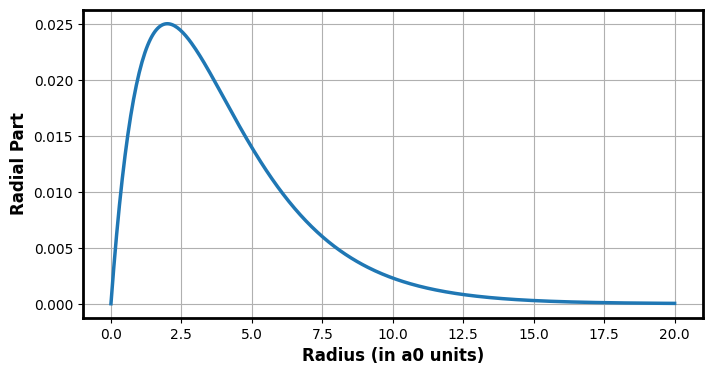

In [ ]:
# Plot the radial part for n=2, l=1
plot_radial_part(2, 1)

In [ ]:
def plot_angular_part(l, m): ### ϕ, θ and ϕ
    """
    Plot the angular part of the wave function for the hydrogen atom.

    Parameters:
    l (int): Azimuthal quantum number
    m (int): Magnetic quantum number

    Returns:
    None. Directly displays the plot.
    """
    # Define the range of theta and phi
    theta = np.linspace(0, np.pi, 100)
    phi = np.linspace(0, 2 * np.pi, 100)
    Theta, Phi = np.meshgrid(theta, phi)

    # Angular part calculation
    angular_part = np.abs(sph_harm(m, l, Phi, Theta))**2

    # Plot
    plt.figure(figsize=(8, 8))
    plt.subplot(projection="polar")
    plt.pcolormesh(Phi, Theta, angular_part)
    plt.title(f'Angular Part of Wave Function (l={l}, m={m})')
    plt.grid(True)
    plt.show()


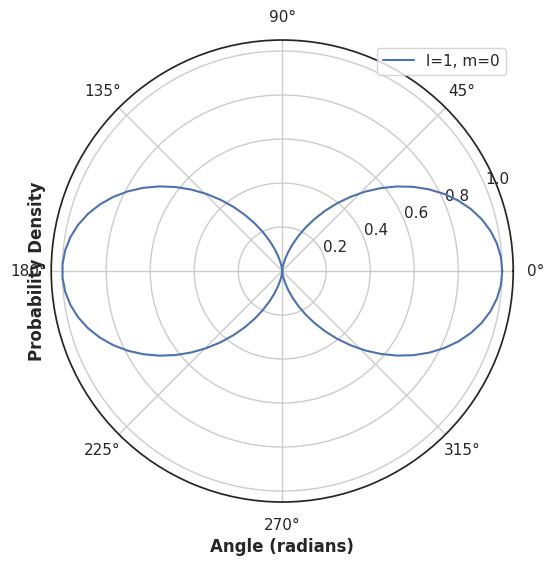

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the angular part of the wavefunction
l = 1  # Azimuthal quantum number
m = 0  # Magnetic quantum number (for 2D, m goes from -l to l)

# Angular variable
theta = np.linspace(0, 2 * np.pi, 100)

# Analytical form of the angular part (using spherical harmonics on a circle)
# For l=1, m=0, the angular part is proportional to cos(theta)
# For l=1, m=1, the angular part is proportional to sin(theta)
# We are plotting the probability density, so we square the function.
if m == 0:
    angular_part = np.cos(theta)
elif abs(m) == 1:
    angular_part = np.sin(theta)
else:
    # For other l, m values, the forms are more complex (associated Legendre polynomials)
    # This simplified example only covers l=1
    angular_part = np.zeros_like(theta) # Placeholder for unsupported values

probability_density_angular = angular_part**2

# Plotting in polar coordinates
plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)

# Plot the probability density
ax.plot(theta, probability_density_angular, label=f'l={l}, m={m}')

# Add labels
# ax.set_title(f'Angular Probability Density ($|Y_{{{l},{m}}}|^2$)', va='bottom', fontsize=14, fontweight='bold') # Removed title
ax.set_xlabel('Angle (radians)', fontsize=12, fontweight='bold') # Make xlabel bold and larger
ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold') # Make ylabel bold and larger

# Set the angular axis to go from 0 to 2pi
ax.set_thetamin(0)
ax.set_thetamax(360)

# Optional: set the radial limits for clarity
# ax.set_ylim(0, max(probability_density_angular) * 1.1) # Adjust as needed

ax.grid(True)
ax.legend()
plt.show()

In [ ]:
def calculate_hydrogen_density_2d(n, l, m, a0=1.0, grid_size=100):
    """
    Calculate the 2D probability density of a hydrogen atom orbital.

    Parameters:
    n (int): Principal quantum number (defines the energy level).
    l (int): Azimuthal quantum number (defines the shape of the orbital).
    m (int): Magnetic quantum number (defines the orientation of the orbital).
    a0 (float): Bohr radius (default is 1.0).
    grid_size (int): Resolution of the grid for calculations.

    Returns:
    X, Y, density: 2D arrays representing the X, Y coordinates and the corresponding probability density.
    """
    # Generate grid
    x = np.linspace(-10*a0, 10*a0, grid_size)
    y = np.linspace(-10*a0, 10*a0, grid_size)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)  # 2D plane cross-section at Z=0

    # Convert to spherical coordinates
    R = np.sqrt(X**2 + Y**2 + Z**2)
    Theta = np.arctan2(np.sqrt(X**2 + Y**2), Z)
    Phi = np.arctan2(Y, X)

    # Radial part of the wave function
    rho = 2 * R / n / a0
    radial_part = np.exp(-rho / 2) * rho**l

    # Angular part of the wave function
    angular_part = np.abs(sph_harm(m, l, Phi, Theta))**2

    # Probability density
    density = radial_part * angular_part

    return X, Y, density

def plot_hydrogen_density_2d(X, Y, density):
    """
    Plot the 2D probability density of the hydrogen atom orbital.

    Parameters:
    X, Y: 2D arrays representing the X and Y coordinates.
    density: 2D array representing the probability density at each (X, Y) coordinate.

    Returns:
    None. The function directly displays the plot.
    """
    plt.figure(figsize=(6, 6))
    plt.pcolormesh(X, Y, density, shading='auto')
    plt.colorbar(label='Probability Density')
    #plt.title('Hydrogen Atom Orbital (2D cross-section)')
    plt.xlabel('x (in a0 units)')
    plt.ylabel('y (in a0 units)')
    plt.axis('equal')
    plt.show()

/tmp/ipython-input-428559299.py:31: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  angular_part = np.abs(sph_harm(m, l, Phi, Theta))**2


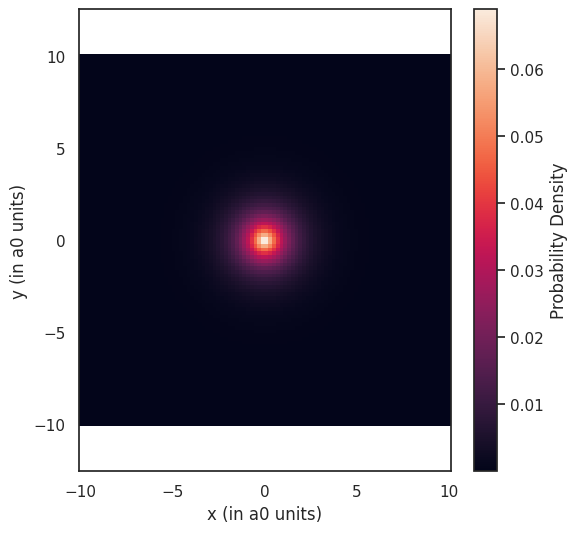

In [ ]:
# Plot the 1s and 2p orbitals in 2D
X, Y, density = calculate_hydrogen_density_2d(1, 0, 0)
plot_hydrogen_density_2d(X, Y, density) # 1s orbital

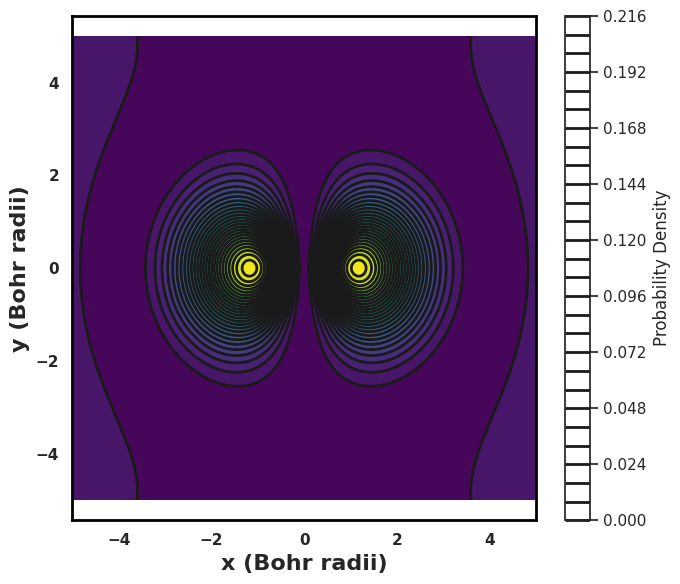

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the orbital
n = 2 # Principal quantum number
l = 1 # Azimuthal quantum number
m = 0 # Magnetic quantum number (for 2D, m goes from -l to l)

# Grid parameters (choose a suitable range and resolution)
L = 10.0 # Size of the box (-L/2 to L/2 in both x and y)
N = 200  # Number of grid points per dimension
dx = L / N

# Create the grid
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x, y)
r = np.sqrt(X**2 + Y**2) # Radial distance
theta = np.arctan2(Y, X) # Angular position

# --- Analytical wave function components (simplified for 2D) ---
# Radial part (example for n=2, l=1) - needs to have a radial node
# The exact form involves associated Laguerre polynomials.
# A simplified form showing the node might look something like (r * exp(-r/n)) * (1 - r/something)
# For n=2, l=1, there's a radial node at r=2n/Z = 4/Z. For Z=1, node at r=4.
# Let's use a form that shows this behavior qualitatively.
# This is NOT the exact analytical radial function, but captures the node.
radial_part = r * np.exp(-r / n) * (1 - r / (2*n)) # Qualitative form with node near r=4 for n=2

# Angular part (using spherical harmonics on a circle)
# Y_{l,m} in 2D is proportional to exp(i * m * theta)
# However, for plotting real orbitals (like px, py), we use linear combinations:
# p_x ~ Y_{1,0} is proportional to cos(theta)
# p_y ~ Y_{1,1} + Y_{1,-1} is proportional to sin(theta)
# We are plotting for l=1, m=0, which is p_x like, proportional to cos(theta)
if m == 0:
    angular_part = np.cos(theta)
elif abs(m) == 1:
    angular_part = np.sin(theta) # For m=1 or m=-1 (px or py like)
else:
     angular_part = np.ones_like(theta) # Placeholder or simplified for s-like

# Combine radial and angular parts to get the full wavefunction
psi = radial_part * angular_part

# Calculate the probability density
probability_density = np.abs(psi)**2

# --- Plotting the 2D probability density ---
plt.figure(figsize=(7, 6))

# Use contourf for filled contours
plt.contourf(X, Y, probability_density, levels=30, cmap='viridis')

# Add contour lines on top of filled contours for better definition
# Set linewidth to 2 as requested
contour_lines = plt.contour(X, Y, probability_density, levels=30, colors='k', linewidths=2) # Added contour lines with linewidth=2

plt.colorbar(label='Probability Density')

# Add labels
# plt.title(f'2D Probability Density (n={n}, l={l}, m={m})', fontsize=14, fontweight='bold') # Removed title
plt.xlabel('x (Bohr radii)', fontsize=16, fontweight='bold') # Made xlabel bold and larger
plt.ylabel('y (Bohr radii)', fontsize=16, fontweight='bold') # Made ylabel bold and larger


# Make axes lines bold and thicker
ax = plt.gca() # Get current axes
for spine in ax.spines.values():
    spine.set_linewidth(2.0) # Set box line width
    spine.set_edgecolor('black')

# Make tick labels bold
for tick in ax.get_xticklabels():
    tick.set_weight('bold')
for tick in ax.get_yticklabels():
    tick.set_weight('bold')


plt.axis('equal') # Make sure x and y axes have the same scale
plt.tight_layout()
plt.show()

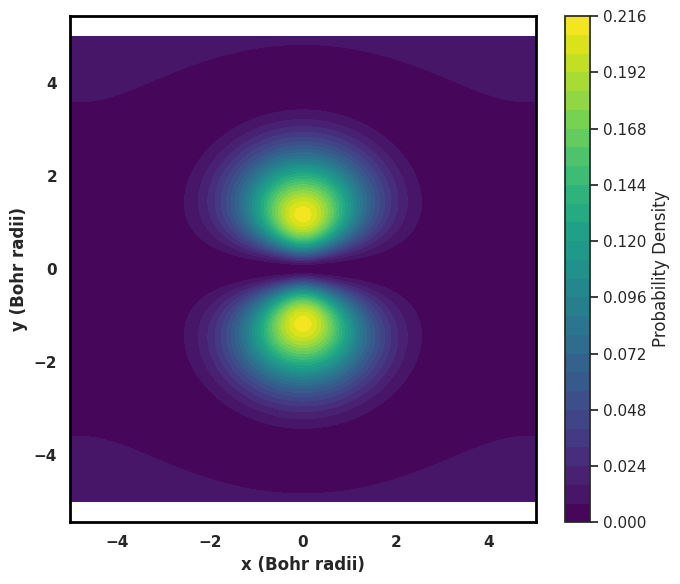

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the orbital
n = 2 # Principal quantum number
l = 1 # Azimuthal quantum number
m = 1 # Magnetic quantum number

# Grid parameters (choose a suitable range and resolution)
L = 10.0 # Size of the box (-L/2 to L/2 in both x and y)
N = 200  # Number of grid points per dimension
dx = L / N

# Create the grid
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x, y)
r = np.sqrt(X**2 + Y**2) # Radial distance
theta = np.arctan2(Y, X) # Angular position

# --- Analytical wave function components (simplified for 2D) ---
# Radial part (example for n=2, l=1)
# Qualitative form with node near r=4 for n=2
radial_part = r * np.exp(-r / n) * (1 - r / (2*n))

# Angular part (for l=1, m=1, which is p_y like)
# Proportional to sin(theta)
if abs(m) == 1:
    angular_part = np.sin(theta) # For m=1 or m=-1 (px or py like)
else:
     angular_part = np.ones_like(theta) # Placeholder or simplified


# Combine radial and angular parts
psi = radial_part * angular_part

# Calculate the probability density
probability_density = np.abs(psi)**2

# --- Plotting the 2D probability density ---
plt.figure(figsize=(7, 6))

# Use contourf for filled contours
plt.contourf(X, Y, probability_density, levels=30, cmap='viridis')
plt.colorbar(label='Probability Density')

# Add labels
# plt.title(f'2D Probability Density (n={n}, l={l}, m={m})', fontsize=14) # Removed title
plt.xlabel('x (Bohr radii)', fontweight='bold') # Make xlabel bold
plt.ylabel('y (Bohr radii)', fontweight='bold') # Make ylabel bold

# Make axes lines bold and thicker
ax = plt.gca() # Get current axes
for spine in ax.spines.values():
    spine.set_linewidth(2.0) # Set box line width
    spine.set_edgecolor('black')

# Make tick labels bold
for tick in ax.get_xticklabels():
    tick.set_weight('bold')
for tick in ax.get_yticklabels():
    tick.set_weight('bold')


plt.axis('equal') # Make sure x and y axes have the same scale
plt.tight_layout()
plt.show()


Simulating the 2D Heat Equation...


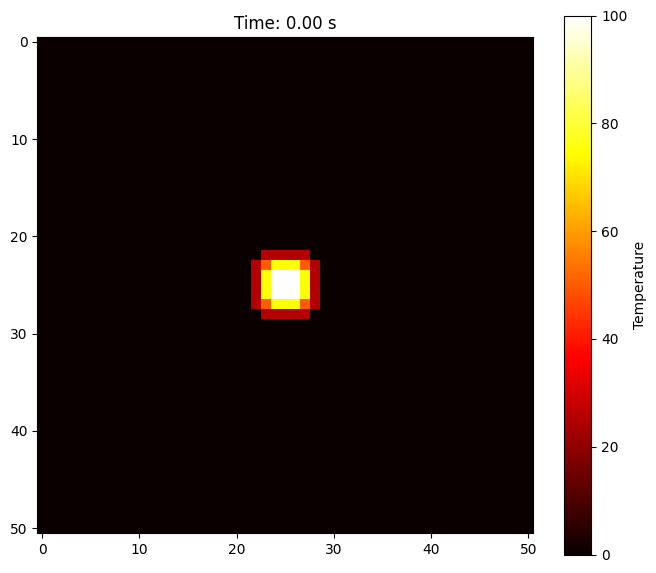

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("\nSimulating the 2D Heat Equation...")

# --- 1. Setup Grid and Parameters ---
N = 51          # Grid points (should be odd for a center point)
L = 1.0         # Size of the plate
dx = L / (N - 1)  # Space step
alpha = 0.01      # Thermal diffusivity
dt = dx**2 / (4 * alpha) # Time step (chosen for stability)
timesteps = 500

# Initialize temperature grid
u = np.zeros((N, N))

# Initial condition: a hot spot in the center
center = N // 2
u[center-2:center+3, center-2:center+3] = 100.0

# --- 2. Set up the Plot for Animation ---
plt.ion() # Turn on interactive mode
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(u, cmap='hot', vmin=0, vmax=100)
ax.set_title("Time: 0.00 s")
cbar = fig.colorbar(im)
cbar.set_label("Temperature")

# --- 3. Time Evolution Loop ---
def laplacian2d(Z, dx):
    """Calculates the 2D Laplacian of an array Z."""
    Z_top   = Z[0:-2, 1:-1]
    Z_left  = Z[1:-1, 0:-2]
    Z_bottom= Z[2:, 1:-1]
    Z_right = Z[1:-1, 2:]
    Z_center= Z[1:-1, 1:-1]
    return (Z_top + Z_left + Z_bottom + Z_right - 4 * Z_center) / dx**2

for i in range(timesteps):
    # Calculate the change in temperature
    delta_u = dt * alpha * laplacian2d(u, dx)

    # Update the inner part of the grid
    u[1:-1, 1:-1] += delta_u

    # Update the plot periodically
    if i % 10 == 0:
        im.set_data(u)
        ax.set_title(f"Time: {i*dt:.2f} s")
        fig.canvas.draw()
        plt.pause(0.01)

plt.ioff() # Turn off interactive mode
ax.set_title(f"Final Temperature Distribution (Time: {timesteps*dt:.2f} s)")
plt.show()


Solving Laplace's Equation for Electric Potential...
Iterating up to 5000 times...
Reached maximum iterations without converging.


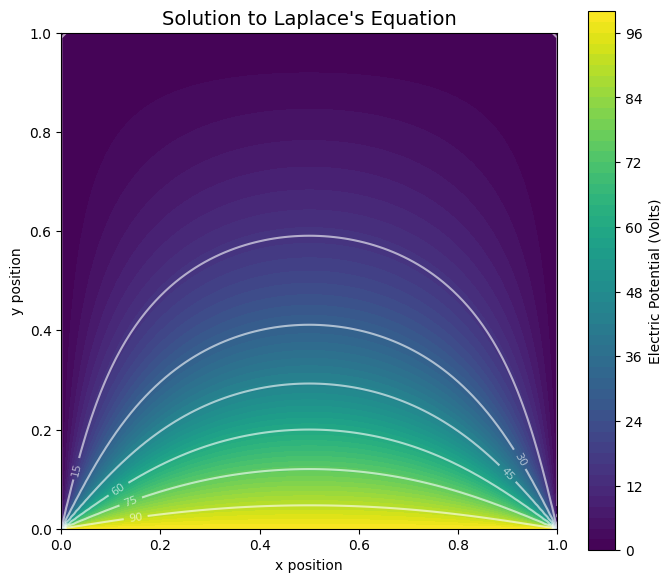

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("\nSolving Laplace's Equation for Electric Potential...")

# --- 1. Setup Grid and Boundary Conditions ---
N = 101 # Grid points
V = np.zeros((N, N)) # Initialize potential grid to zero

# Set boundary conditions
V[0, :] = 100.0   # Top wall at 100 Volts
V[-1, :] = 0.0    # Bottom wall at 0 Volts
V[:, 0] = 0.0     # Left wall at 0 Volts
V[:, -1] = 0.0    # Right wall at 0 Volts

# --- 2. Iterative Solver Loop ---
max_iter = 5000
tolerance = 1e-5
print(f"Iterating up to {max_iter} times...")

for iteration in range(max_iter):
    V_old = V.copy()

    # Update each interior point to be the average of its neighbors
    V[1:-1, 1:-1] = 0.25 * (V_old[0:-2, 1:-1] + V_old[2:, 1:-1] +
                              V_old[1:-1, 0:-2] + V_old[1:-1, 2:])

    # Check for convergence
    if np.max(np.abs(V - V_old)) < tolerance:
        print(f"Converged after {iteration} iterations.")
        break
else: # This 'else' belongs to the 'for' loop, runs if no 'break'
    print("Reached maximum iterations without converging.")

# --- 3. Plot the Results ---
x = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, x)

plt.figure(figsize=(8, 7))
# Change 'electric' to a valid colormap, e.g., 'viridis'
plt.contourf(X, Y, V, levels=50, cmap='viridis')
cbar = plt.colorbar()
cbar.set_label("Electric Potential (Volts)")

# Add contour lines for clarity
contours = plt.contour(X, Y, V, colors='white', alpha=0.6)
plt.clabel(contours, inline=True, fontsize=8)

plt.title("Solution to Laplace's Equation", fontsize=14)
plt.xlabel("x position")
plt.ylabel("y position")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Iteration 500: Energy = 0.191885
Iteration 1000: Energy = -3.155352
Iteration 1500: Energy = -5.013712
Iteration 2000: Energy = -5.343203
Iteration 2500: Energy = -5.379881
Iteration 3000: Energy = -5.383772
Iteration 3500: Energy = -5.384187
Iteration 4000: Energy = -5.384233
Iteration 4500: Energy = -5.384237
Iteration 5000: Energy = -5.384238

Final <x> = -3.754516


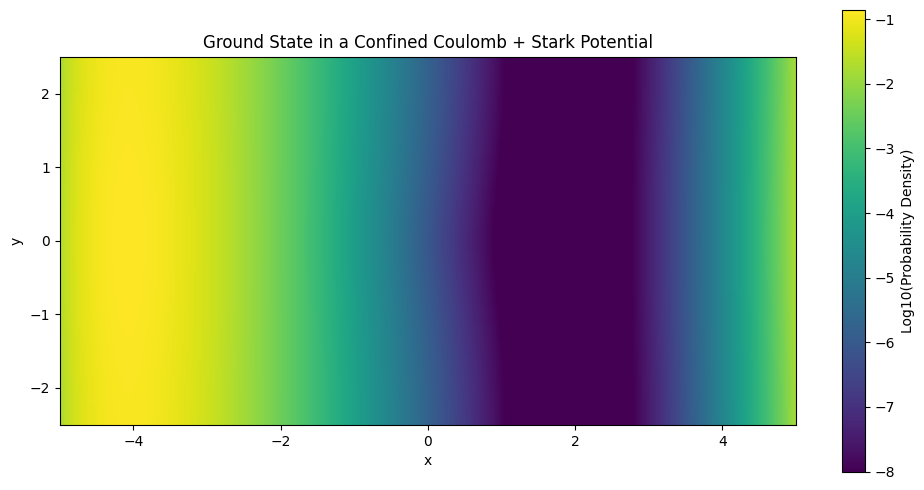

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Lx, Ly = 10.0, 5.0        # Domain size
Nx, Ny = 512, 256         # Grid resolution
dx, dy = Lx / Nx, Ly / Ny   # Grid spacing
x = np.linspace(-Lx/2, Lx/2, Nx)
y = np.linspace(-Ly/2, Ly/2, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')  # Cartesian coordinates
r = np.sqrt(X**2 + Y**2)                 # Radial distance

# Regularized 2D Coulomb potential with Stark term and confinement
epsilon = dx                       # Regularization parameter
E = 1.5                            # Electric field strength
alpha = 0.05                       # Strength of the harmonic confinement
V = -np.log(r + epsilon) + E * X + alpha * r**2   # Coulomb + Stark + Confinement

# Initial wavefunction: A wider Gaussian is often more stable
psi = np.exp(-1.0 * ((X - 0.6)**2 + Y**2))

# Fourier space variables
# --- THIS IS THE CRITICAL FIX ---
# Correctly define the wavevectors using the grid spacing dx and dy
kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)
# --- End of fix ---

KX, KY = np.meshgrid(kx, ky, indexing='ij')
# In our units (hbar=1, 2m=1), Kinetic Energy = p^2 = k^2
K_sq = KX**2 + KY**2

# Time evolution parameters
dt = 0.001
nt = 5000

# Imaginary Time Evolution using a symmetric split-step method
for i in range(nt):
    # Half-step in potential
    psi *= np.exp(-V * dt / 2)

    # Full-step in kinetic energy (in Fourier space)
    psi_k = np.fft.fft2(psi)
    psi_k *= np.exp(-K_sq * dt) # Note: full dt step for kinetic part
    psi = np.fft.ifft2(psi_k)

    # Another half-step in potential
    psi *= np.exp(-V * dt / 2)

    # Normalize
    norm = np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)
    psi /= norm

    # Track convergence (optional, but good for checking)
    if (i + 1) % 500 == 0:
        energy = np.real(np.sum(np.conj(psi) * (np.fft.ifft2(K_sq * np.fft.fft2(psi)) + V*psi)) * dx * dy)
        print(f"Iteration {i+1}: Energy = {energy:.6f}")

# Compute final expectation value of x
x_expectation = np.sum(X * np.abs(psi)**2 * dx * dy)
print(f"\nFinal <x> = {x_expectation:.6f}")

# Plot final wavefunction (log scale)
plt.figure(figsize=(10, 5))
prob = np.abs(psi)**2
plt.imshow(np.log10(prob.T),
           extent=[-Lx/2, Lx/2, -Ly/2, Ly/2],
           cmap='viridis', aspect='equal', origin='lower',
           vmin=-8, vmax=np.log10(prob.max()))
plt.colorbar(label='Log10(Probability Density)')
plt.title('Ground State in a Confined Coulomb + Stark Potential')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

Starting final simulation...
Iteration 1000/4000 complete.
Iteration 2000/4000 complete.
Iteration 3000/4000 complete.
Iteration 4000/4000 complete.

Evolution finished.


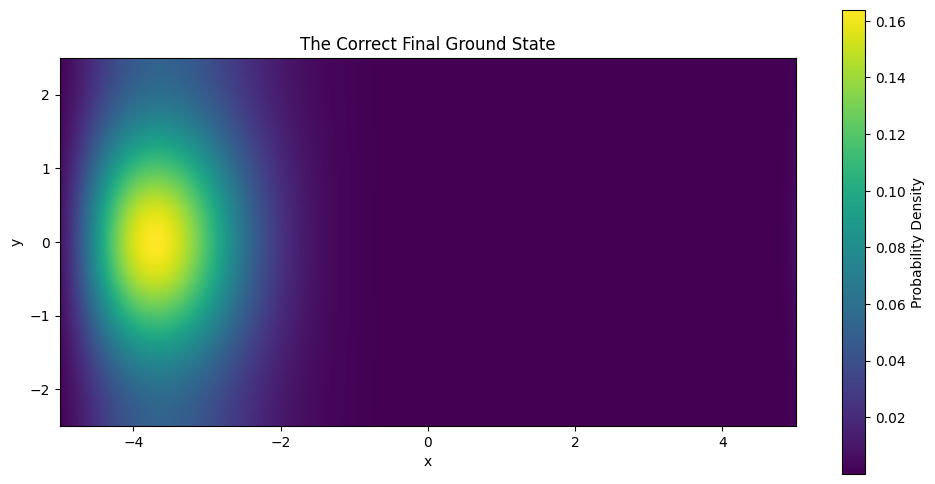

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===================================================================
# 1. SETUP THE PHYSICAL SYSTEM
# ===================================================================

# -- System Parameters (hbar=1, mass=1) --
hbar = 1.0
mass = 1.0

# -- Domain and Grid --
Lx, Ly = 10.0, 5.0
Nx, Ny = 512, 256
dx, dy = Lx / Nx, Ly / Ny

# -- Coordinates --
x_vec = np.linspace(-Lx/2, Lx/2, Nx)
y_vec = np.linspace(-Ly/2, Ly/2, Ny)

# --- THE FIX, PART 1: Use 'xy' indexing for all spatial arrays ---
# This is the standard convention. It makes arrays have shape (Ny, Nx).
X, Y = np.meshgrid(x_vec, y_vec, indexing='xy')
r = np.sqrt(X**2 + Y**2)

# -- Potential Energy (V) --
epsilon = dx
E_field = 1.5
alpha = 0.05
V = -np.log(r + epsilon) + E_field * X + alpha * r**2

# ===================================================================
# 2. SETUP THE NUMERICAL METHOD
# ===================================================================

# -- Fourier Space (k-space) for Kinetic Energy --
kx_vec = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky_vec = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)

# --- THE FIX, PART 2: Use matching 'xy' indexing for k-space arrays ---
KX, KY = np.meshgrid(kx_vec, ky_vec, indexing='xy')

# Kinetic Energy Operator in k-space: T = (hbar^2 * k^2) / 2m
K_squared = KX**2 + KY**2
T_operator = (hbar**2 * K_squared) / (2 * mass)

# -- Time Evolution Parameters --
dt = 0.0005
nt = 4000

# -- Initial Wavefunction --
# This will now correctly have shape (Ny, Nx)
psi = np.exp(-1.0 * ((X - 0.6)**2 + Y**2))
psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)

# ===================================================================
# 3. IMAGINARY TIME EVOLUTION LOOP
# ===================================================================
# The logic inside the loop is unchanged, as all arrays are now consistent.

print("Starting final simulation...")
for i in range(nt):
    psi *= np.exp(-V * dt / (2 * hbar))
    psi_k = np.fft.fft2(psi)
    psi_k *= np.exp(-T_operator * dt / hbar)
    psi = np.fft.ifft2(psi_k)
    psi *= np.exp(-V * dt / (2 * hbar))
    psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)
    if (i + 1) % 1000 == 0:
        print(f"Iteration {i+1}/{nt} complete.")
print("\nEvolution finished.")


# ===================================================================
# 4. ANALYSIS AND PLOTTING
# ===================================================================
prob_density = np.abs(psi)**2

plt.figure(figsize=(10, 5))

# --- THE FIX, PART 3: Remove the transpose (.T) from imshow ---
# Because our array is now (y, x), it matches what imshow expects.
plt.imshow(prob_density,
           extent=[-Lx/2, Lx/2, -Ly/2, Ly/2],
           cmap='viridis', aspect='equal', origin='lower',
           vmin=1e-9) # Using a small number for vmin, as log(0) is -inf

plt.colorbar(label='Probability Density')
plt.title('The Correct Final Ground State')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

Starting final simulation...
Iteration 1000/4000 complete.
Iteration 2000/4000 complete.
Iteration 3000/4000 complete.
Iteration 4000/4000 complete.

Evolution finished.


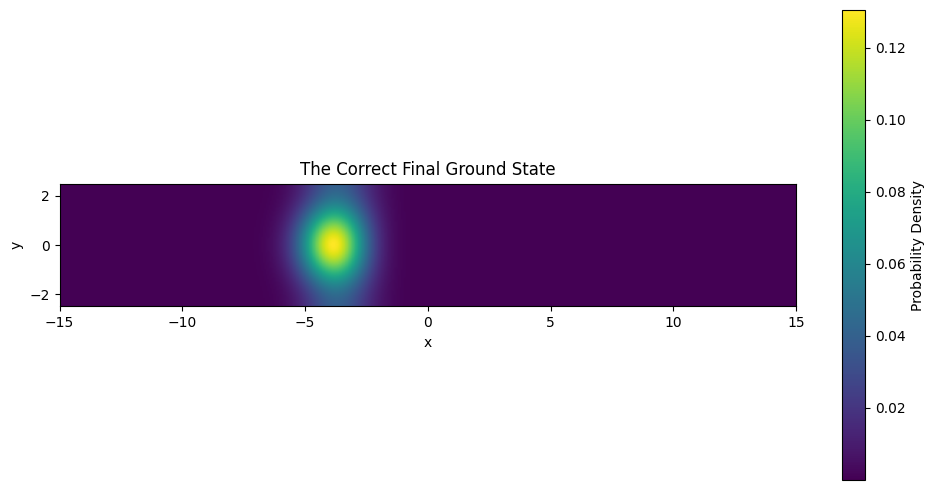

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===================================================================
# 1. SETUP THE PHYSICAL SYSTEM
# ===================================================================

# -- System Parameters (hbar=1, mass=1) --
hbar = 1.0
mass = 1.0

# -- Domain and Grid --
Lx, Ly = 30.0, 5.0
Nx, Ny = 512, 256
dx, dy = Lx / Nx, Ly / Ny

# -- Coordinates --
x_vec = np.linspace(-Lx/2, Lx/2, Nx)
y_vec = np.linspace(-Ly/2, Ly/2, Ny)

# --- THE FIX, PART 1: Use 'xy' indexing for all spatial arrays ---
# This is the standard convention. It makes arrays have shape (Ny, Nx).
X, Y = np.meshgrid(x_vec, y_vec, indexing='xy')
r = np.sqrt(X**2 + Y**2)

# -- Potential Energy (V) --
epsilon = dx
E_field = 1.5
alpha = 0.05
V = -np.log(r + epsilon) + E_field * X + alpha * r**2

# ===================================================================
# 2. SETUP THE NUMERICAL METHOD
# ===================================================================

# -- Fourier Space (k-space) for Kinetic Energy --
kx_vec = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky_vec = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)

# --- THE FIX, PART 2: Use matching 'xy' indexing for k-space arrays ---
KX, KY = np.meshgrid(kx_vec, ky_vec, indexing='xy')

# Kinetic Energy Operator in k-space: T = (hbar^2 * k^2) / 2m
K_squared = KX**2 + KY**2
T_operator = (hbar**2 * K_squared) / (2 * mass)

# -- Time Evolution Parameters --
dt = 0.0005
nt = 4000

# -- Initial Wavefunction --
# This will now correctly have shape (Ny, Nx)
psi = np.exp(-1.0 * ((X - 0.6)**2 + Y**2))
psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)

# ===================================================================
# 3. IMAGINARY TIME EVOLUTION LOOP
# ===================================================================
# The logic inside the loop is unchanged, as all arrays are now consistent.

print("Starting final simulation...")
for i in range(nt):
    psi *= np.exp(-V * dt / (2 * hbar))
    psi_k = np.fft.fft2(psi)
    psi_k *= np.exp(-T_operator * dt / hbar)
    psi = np.fft.ifft2(psi_k)
    psi *= np.exp(-V * dt / (2 * hbar))
    psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)
    if (i + 1) % 1000 == 0:
        print(f"Iteration {i+1}/{nt} complete.")
print("\nEvolution finished.")


# ===================================================================
# 4. ANALYSIS AND PLOTTING
# ===================================================================
prob_density = np.abs(psi)**2

plt.figure(figsize=(10, 5))

# --- THE FIX, PART 3: Remove the transpose (.T) from imshow ---
# Because our array is now (y, x), it matches what imshow expects.
plt.imshow(prob_density,
           extent=[-Lx/2, Lx/2, -Ly/2, Ly/2],
           cmap='viridis', aspect='equal', origin='lower',
           vmin=1e-9) # Using a small number for vmin, as log(0) is -inf

plt.colorbar(label='Probability Density')
plt.title('The Correct Final Ground State')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

Setting up 2D Helium simulation...
Starting evolution on a 64x64x64x64 grid...
Iteration 100/1000 complete.
Iteration 200/1000 complete.
Iteration 300/1000 complete.
Iteration 400/1000 complete.
Iteration 500/1000 complete.
Iteration 600/1000 complete.
Iteration 700/1000 complete.
Iteration 800/1000 complete.
Iteration 900/1000 complete.
Iteration 1000/1000 complete.

Evolution finished.
Calculating one-electron density...


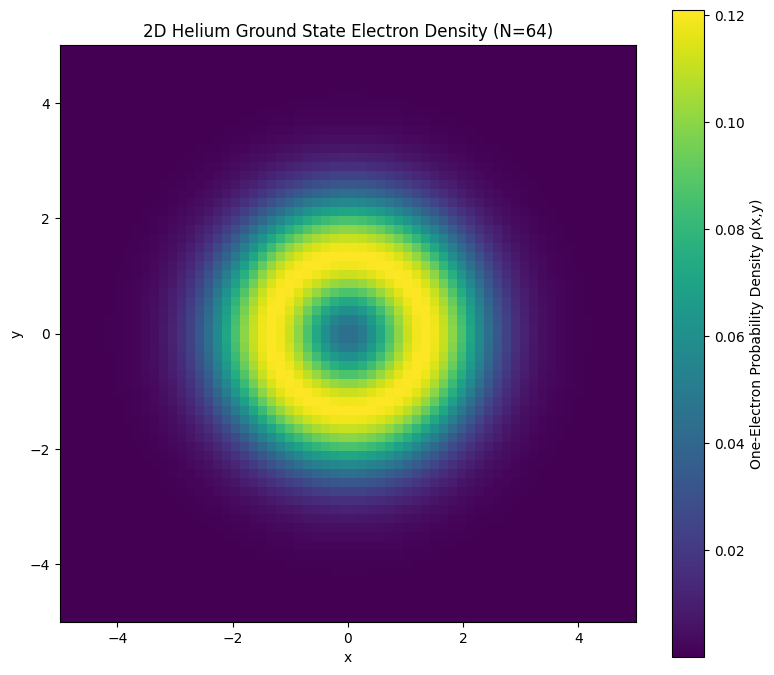

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===================================================================
# 1. SETUP THE 2D HELIUM SYSTEM
# ===================================================================
print("Setting up 2D Helium simulation...")

# -- System Parameters (hbar=1, mass=1) --
hbar = 1.0
mass = 1.0
Z = 2.0  # Nuclear charge for Helium

# -- Domain and Grid --
# We must use a coarse grid for a 4D simulation to be feasible.
N = 64                   # Number of grid points PER dimension
L = 10.0                  # Domain size (-L/2 to L/2)
dx = L / N               # Grid spacing

# -- 1D Coordinates and k-vectors --
x_vec = np.linspace(-L/2, L/2, N)
k_vec = 2 * np.pi * np.fft.fftfreq(N, d=dx)

# -- Create 4D Coordinate Grids --
# We use broadcasting to build 4D arrays without huge memory overhead initially
X1, Y1, X2, Y2 = np.meshgrid(x_vec, x_vec, x_vec, x_vec, indexing='ij')

# -- Potential Energy (V) --
# Note: r1, r2, r12 are now 4D arrays
r1 = np.sqrt(X1**2 + Y1**2)
r2 = np.sqrt(X2**2 + Y2**2)
r12 = np.sqrt((X1 - X2)**2 + (Y1 - Y2)**2)

epsilon = dx/2  # Regularization to prevent division by zero

# Full potential V(x1, y1, x2, y2)
V = -Z * np.log(r1 + epsilon) - Z * np.log(r2 + epsilon) + np.log(r12 + epsilon)


# ===================================================================
# 2. SETUP THE NUMERICAL METHOD
# ===================================================================

# -- 4D Fourier Space (k-space) --
KX1, KY1, KX2, KY2 = np.meshgrid(k_vec, k_vec, k_vec, k_vec, indexing='ij')

# Kinetic Energy Operator in k-space for two particles
K_squared_1 = KX1**2 + KY1**2
K_squared_2 = KX2**2 + KY2**2
T_operator = (hbar**2 / (2 * mass)) * (K_squared_1 + K_squared_2)

# -- Time Evolution Parameters --
dt = 0.001
nt = 1000  # A few hundred steps is enough for a coarse grid

# -- Initial Wavefunction psi(x1, y1, x2, y2) --
# We start with a symmetric state (product of two Gaussians)
psi = np.exp(-Z * r1) * np.exp(-Z * r2)
psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx**4) # Normalize over 4D volume


# ===================================================================
# 3. IMAGINARY TIME EVOLUTION LOOP
# ===================================================================
print(f"Starting evolution on a {N}x{N}x{N}x{N} grid...")

for i in range(nt):
    # Use the symmetric split-step method
    psi *= np.exp(-V * dt / (2 * hbar))

    # Evolve in k-space using n-dimensional FFT
    psi_k = np.fft.fftn(psi)
    psi_k *= np.exp(-T_operator * dt / hbar)
    psi = np.fft.ifftn(psi_k)

    psi *= np.exp(-V * dt / (2 * hbar))
    psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx**4)

    if (i + 1) % 100 == 0:
        print(f"Iteration {i+1}/{nt} complete.")

print("\nEvolution finished.")

# ===================================================================
# 4. ANALYSIS AND PLOTTING
# ===================================================================
print("Calculating one-electron density...")

# Calculate the probability density of finding *an* electron at (x,y)
# rho(x,y) = integral(|psi(x,y,x2,y2)|^2 dx2 dy2) + integral(|psi(x1,y1,x,y)|^2 dx1 dy1)
# By symmetry, the two terms are identical.
# We sum over the axes corresponding to the second particle (axes 2 and 3)
one_electron_density = 2 * np.sum(np.abs(psi)**2, axis=(2, 3)) * dx**2

# Plot the resulting 2D density
plt.figure(figsize=(8, 7))
plt.imshow(one_electron_density.T,
           extent=[-L/2, L/2, -L/2, L/2],
           cmap='viridis', origin='lower')

plt.colorbar(label='One-Electron Probability Density ρ(x,y)')
plt.title(f'2D Helium Ground State Electron Density (N={N})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

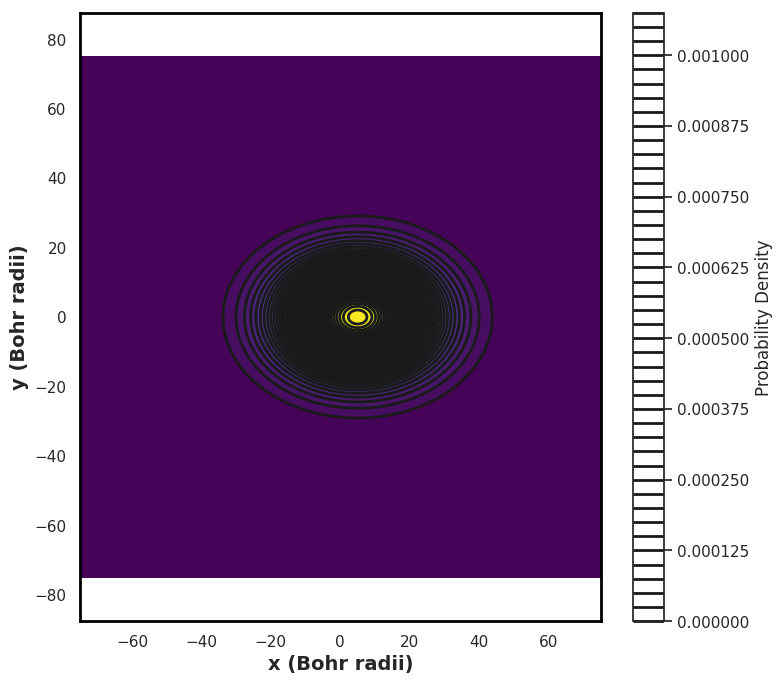

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Nx, Ny = 1024, 512  # Grid size
Lx, Ly = 40.0, 20.0  # Domain size
dx, dy = Lx / Nx, Ly / Ny  # Grid spacing
dt = 0.0001  # Time step
nt = 20000  # Number of time steps
E = 0.1  # Electric field strength

# Coordinate arrays (with 'ij' indexing for consistency)
x = np.linspace(-Lx/2, Lx/2, Nx, endpoint=False)
y = np.linspace(-Ly/2, Ly/2, Ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')  # Corrected indexing
r = np.sqrt(X**2 + Y**2)

# Potential: -log(r + epsilon) + E * x (regularized 2D Coulomb + Stark term)
epsilon = dx  # Regularization parameter
V = -np.log(r + epsilon) + E * X

# Initial wavefunction: Gaussian centered at (0.7, 0)
psi = np.exp(-((X - 0.7)**2 + Y**2) / 0.2)
psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)  # Normalize

# Kinetic energy operator in Fourier space (with 'ij' indexing)
kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)
KX, KY = np.meshgrid(kx, ky, indexing='ij')  # Corrected indexing
K2 = KX**2 + KY**2
kinetic_factor = np.exp(-0.5 * dt * K2)

# Imaginary time evolution
for t in range(nt):
    # Half-step in real space (potential)
    psi *= np.exp(-0.5 * dt * V)

    # Full step in Fourier space (kinetic)
    psi_fft = np.fft.fft2(psi)
    psi_fft *= kinetic_factor
    psi = np.fft.ifft2(psi_fft)

    # Another half-step in real space (potential)
    psi *= np.exp(-0.5 * dt * V)

    # Normalize
    norm = np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)
    psi /= norm

    # Monitor convergence every 1000 steps
    if t % 1000 == 0:
        x_expect = np.sum(X * np.abs(psi)**2) * dx * dy
        print(f"Step {t}, <x> = {x_expect:.6f}")

# Final expectation value
x_expect = np.sum(X * np.abs(psi)**2) * dx * dy
print(f"Final <x> = {x_expect:.6f}")

# Visualization
plt.contourf(X, Y, np.log(np.abs(psi)**2 + 1e-10), levels=20)
plt.colorbar(label="log(|ψ|²)")
plt.title("Ground State Probability Density")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

Step 0, <x> = 0.700013
Step 1000, <x> = 0.718195
Step 2000, <x> = 0.743556
Step 3000, <x> = 0.773559
Step 4000, <x> = 0.806900
Step 5000, <x> = 0.842869
Step 6000, <x> = 0.881041
Step 7000, <x> = 0.921137
Step 8000, <x> = 0.962961
Step 9000, <x> = 1.006365
Step 10000, <x> = 1.051229
Step 11000, <x> = 1.097453
Step 12000, <x> = 1.144947
Step 13000, <x> = 1.193632
Step 14000, <x> = 1.243432
Step 15000, <x> = 1.294281
Step 16000, <x> = 1.346110
Step 17000, <x> = 1.398859
Step 18000, <x> = 1.452468
Step 19000, <x> = 1.506881
Final <x> = 1.561987


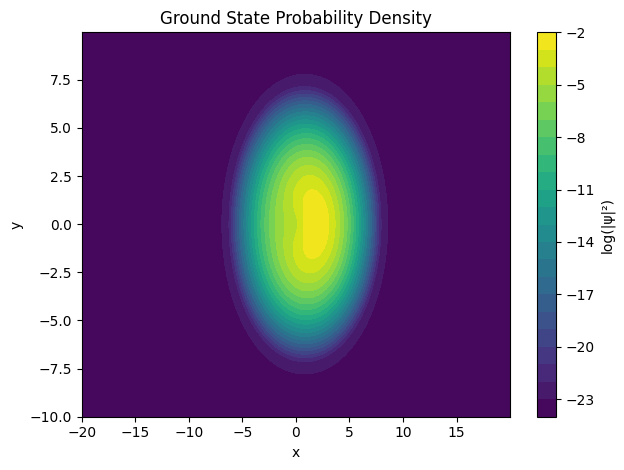

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Nx, Ny = 1024, 512  # Grid size
Lx, Ly = 40.0, 20.0  # Domain size
dx, dy = Lx / Nx, Ly / Ny  # Grid spacing
dt = 0.0001  # Time step
nt = 20000  # Number of time steps
E = 0.0  # Electric field strength

# Coordinate arrays (with 'ij' indexing for consistency)
x = np.linspace(-Lx/2, Lx/2, Nx, endpoint=False)
y = np.linspace(-Ly/2, Ly/2, Ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')  # Corrected indexing
r = np.sqrt(X**2 + Y**2)

# Potential: -log(r + epsilon) + E * x (regularized 2D Coulomb + Stark term)
epsilon = dx  # Regularization parameter
V = -np.log(r + epsilon) + E * X

# Initial wavefunction: Gaussian centered at (0.7, 0)
psi = np.exp(-((X - 0.7)**2 + Y**2) / 0.2)
psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)  # Normalize

# Kinetic energy operator in Fourier space (with 'ij' indexing)
kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)
KX, KY = np.meshgrid(kx, ky, indexing='ij')  # Corrected indexing
K2 = KX**2 + KY**2
kinetic_factor = np.exp(-0.5 * dt * K2)

# Imaginary time evolution
for t in range(nt):
    # Half-step in real space (potential)
    psi *= np.exp(-0.5 * dt * V)

    # Full step in Fourier space (kinetic)
    psi_fft = np.fft.fft2(psi)
    psi_fft *= kinetic_factor
    psi = np.fft.ifft2(psi_fft)

    # Another half-step in real space (potential)
    psi *= np.exp(-0.5 * dt * V)

    # Normalize
    norm = np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)
    psi /= norm

    # Monitor convergence every 1000 steps
    if t % 1000 == 0:
        x_expect = np.sum(X * np.abs(psi)**2) * dx * dy
        print(f"Step {t}, <x> = {x_expect:.6f}")

# Final expectation value
x_expect = np.sum(X * np.abs(psi)**2) * dx * dy
print(f"Final <x> = {x_expect:.6f}")

# Visualization
plt.contourf(X, Y, np.log(np.abs(psi)**2 + 1e-10), levels=20)
plt.colorbar(label="log(|ψ|²)")
plt.title("Ground State Probability Density")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-374419968.py:46: SyntaxWarning: invalid escape sequence '\p'
  plt.colorbar(label='Log Probability Density (log$_{10}|\psi|^2$)')


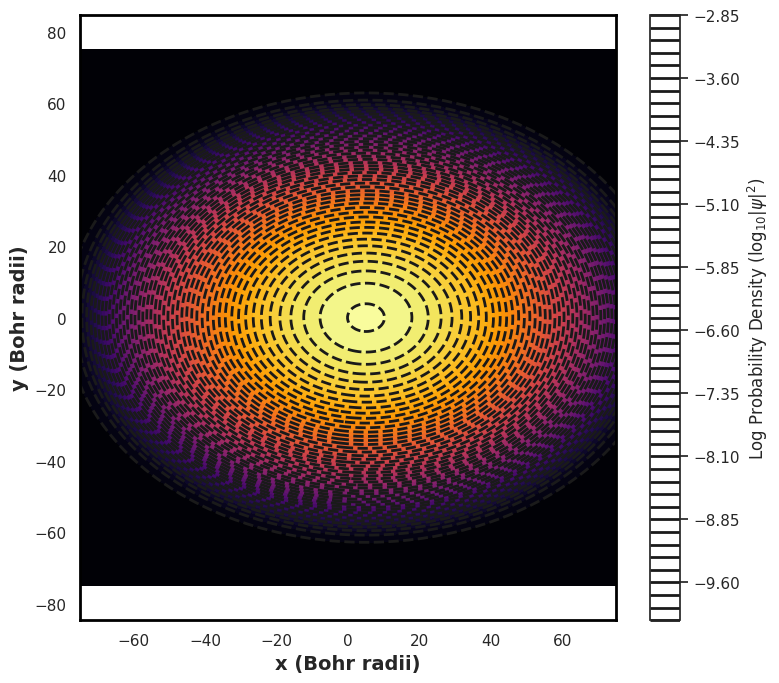

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Nx, Ny = 1024, 512        # Grid resolution
Lx, Ly = 40.0, 20.0       # Domain size
dx, dy = Lx / Nx, Ly / Ny # Grid spacing
dt = 0.00005              # Smaller time step for stability
nt = 100000               # Increased iterations for convergence
E = 0.1                   # Electric field strength (equilibrium at x = 1/E = 10)

# Coordinate arrays (with 'ij' indexing for FFT consistency)
x = np.linspace(-Lx/2, Lx/2, Nx, endpoint=False)
y = np.linspace(-Ly/2, Ly/2, Ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')  # Corrected indexing
r = np.sqrt(X**2 + Y**2)                 # Radial distance

# Potential: -log(r + epsilon) - E * X (correct sign for electron)
epsilon = dx  # Regularization parameter (avoid singularity at r=0)
V = -np.log(r + epsilon) - E * X  # Attractive Coulomb + Stark term (electron)

# Initial wavefunction: Gaussian centered near expected equilibrium (x = 10)
psi = np.exp(-((X - 9.0)**2 + Y**2) / 0.2)  # Start near x=9 (close to x=10)
psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)  # Normalize

# Kinetic energy operator in Fourier space (with 'ij' indexing)
kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)
KX, KY = np.meshgrid(kx, ky, indexing='ij')  # Corrected indexing
K2 = KX**2 + KY**2                          # Kinetic energy in Fourier space
kinetic_factor = np.exp(-0.5 * dt * K2)     # Kinetic propagator

# Imaginary Time Evolution
for t in range(nt):
    # Half-step in real space (potential)
    psi *= np.exp(-0.5 * dt * V)

    # Full step in Fourier space (kinetic)
    psi_fft = np.fft.fft2(psi)
    psi_fft *= kinetic_factor
    psi = np.fft.ifft2(psi_fft)

    # Half-step in real space (potential)
    psi *= np.exp(-0.5 * dt * V)

    # Normalize
    norm = np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)
    psi /= norm

    # Monitor convergence every 1000 steps
    if t % 1000 == 0:
        x_expect = np.sum(X * np.abs(psi)**2) * dx * dy
        print(f"Step {t}, <x> = {x_expect:.6f}")

# Final expectation value
x_expect = np.sum(X * np.abs(psi)**2) * dx * dy
print(f"\nFinal <x> = {x_expect:.6f}")

# Visualization
plt.figure(figsize=(10, 5))
prob = np.abs(psi)**2
prob[prob < 1e-12] = 1e-12  # Avoid log(0)
plt.contourf(X, Y, np.log(prob), levels=20, cmap='viridis')
plt.colorbar(label="Log Probability Density")
plt.title("Ground State of 2D Hydrogen in Electric Field (Electron)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

E_field = 0.00, Ground State Energy = -1.109630
E_field = 0.01, Ground State Energy = -1.109672
E_field = 0.02, Ground State Energy = -1.109799
E_field = 0.03, Ground State Energy = -1.110012
E_field = 0.04, Ground State Energy = -1.110309
E_field = 0.05, Ground State Energy = -1.110694
E_field = 0.10, Ground State Energy = -1.113954


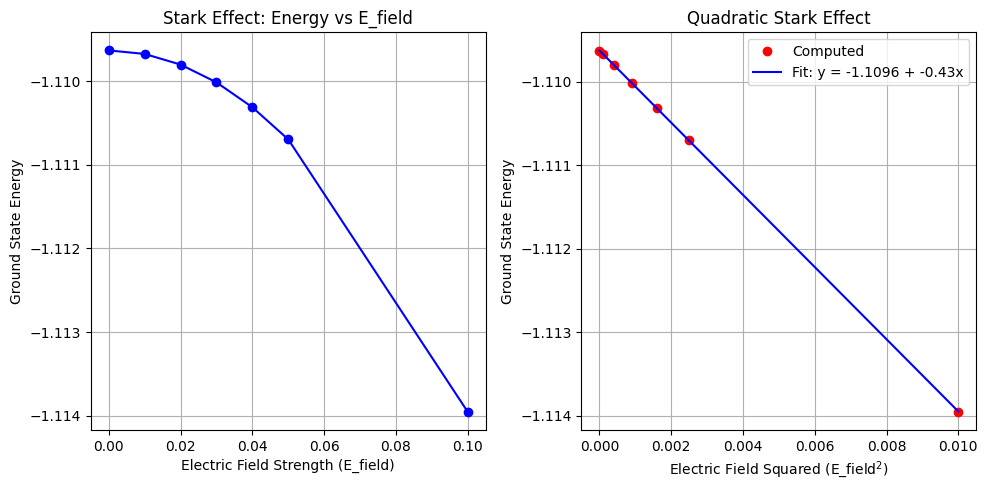


Quadratic Stark coefficient: -0.4327 (energy shift per E_field^2)


In [ ]:
import numpy as np
from scipy.fft import fft2, ifft2, fftfreq
import matplotlib.pyplot as plt

# Parameters
L = 10.0  # Half-size of the simulation box
N = 128   # Number of grid points per dimension
dx = 2 * L / (N - 1)  # Grid spacing
dy = dx
x = np.linspace(-L, L, N)
y = np.linspace(-L, L, N)
X, Y = np.meshgrid(x, y)  # 2D coordinate grid
r = np.sqrt(X**2 + Y**2)  # Radial distance
eps = dx  # Softening parameter to avoid singularity at r=0

# Initial wave function: Gaussian
sigma = 1.0
psi_initial = np.exp(- (X**2 + Y**2) / (2 * sigma**2))
norm_initial = np.sum(np.abs(psi_initial)**2) * dx * dy
psi_initial /= np.sqrt(norm_initial)  # Normalize initial wave function

# Imaginary time evolution parameters
dt = 0.01    # Time step
energy_tolerance = 1e-6  # Convergence criterion

# Momentum space grid for kinetic energy
kx = 2 * np.pi * fftfreq(N, d=dx)
ky = 2 * np.pi * fftfreq(N, d=dy)
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2  # k^2 for kinetic energy operator
T_term = np.exp(-K2 * dt / 2)  # Kinetic operator (constant)

# Energy calculation function
def compute_energy(psi, V):
    psi_k = fft2(psi)
    T_psi = ifft2(0.5 * K2 * psi_k)  # Kinetic energy: (1/2) k^2 psi
    H_psi = T_psi + V * psi          # H psi = T psi + V psi
    energy = np.sum(np.conj(psi) * H_psi) * dx * dy
    return energy.real

# Function for imaginary time propagation
def compute_ground_state(E_field, max_steps=5000):
    # Update potential with current E_field
    V = -1 / np.sqrt(r**2 + eps**2) + E_field * X
    V_term_base = np.exp(-V * dt / 2)  # Potential operator (depends on E_field)

    # Initialize wave function
    psi = psi_initial.copy()
    prev_energy = float('inf')

    # Imaginary time evolution
    for step in range(max_steps):
        # Apply half potential step
        psi *= V_term_base

        # FFT to momentum space and apply kinetic step
        psi_k = fft2(psi)
        psi_k *= T_term
        psi = ifft2(psi_k)

        # Apply second half potential step
        psi *= V_term_base

        # Normalize wave function
        norm = np.sum(np.abs(psi)**2) * dx * dy
        psi /= np.sqrt(norm)

        # Check convergence every 100 steps
        if step % 100 == 0:
            energy = compute_energy(psi, V)
            if abs(prev_energy - energy) < energy_tolerance and step > 100:
                break
            prev_energy = energy

    # Final energy calculation
    energy = compute_energy(psi, V)
    return energy

# Electric field values to study Stark effect
E_field_list = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1]
energies = []

# Compute ground state energies for each E_field
for E_val in E_field_list:
    energy = compute_ground_state(E_val)
    energies.append(energy)
    print(f"E_field = {E_val:.2f}, Ground State Energy = {energy:.6f}")

# Quadratic Stark effect analysis
E_squared = np.array(E_field_list)**2

# Quadratic fit: energy = a + b * E^2
A = np.vstack([E_squared, np.ones(len(E_squared))]).T
b, a = np.linalg.lstsq(A, energies, rcond=None)[0]

# Generate points for quadratic fit curve
E_squared_fit = np.linspace(0, 0.01, 100)
energy_fit = a + b * E_squared_fit

# Plot energy vs electric field strength
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(E_field_list, energies, 'bo-', label='Computed')
plt.xlabel('Electric Field Strength (E_field)')
plt.ylabel('Ground State Energy')
plt.title('Stark Effect: Energy vs E_field')
plt.grid(True)

# Plot energy vs E_field squared with quadratic fit
plt.subplot(1, 2, 2)
plt.plot(E_squared, energies, 'ro', label='Computed')
plt.plot(E_squared_fit, energy_fit, 'b-',
         label=f'Fit: y = {a:.4f} + {b:.2f}x')
plt.xlabel('Electric Field Squared (E_field$^2$)')
plt.ylabel('Ground State Energy')
plt.title('Quadratic Stark Effect')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('stark_effect_analysis.png')
plt.show()

# Print quadratic Stark coefficient
print(f"\nQuadratic Stark coefficient: {b:.4f} (energy shift per E_field^2)")

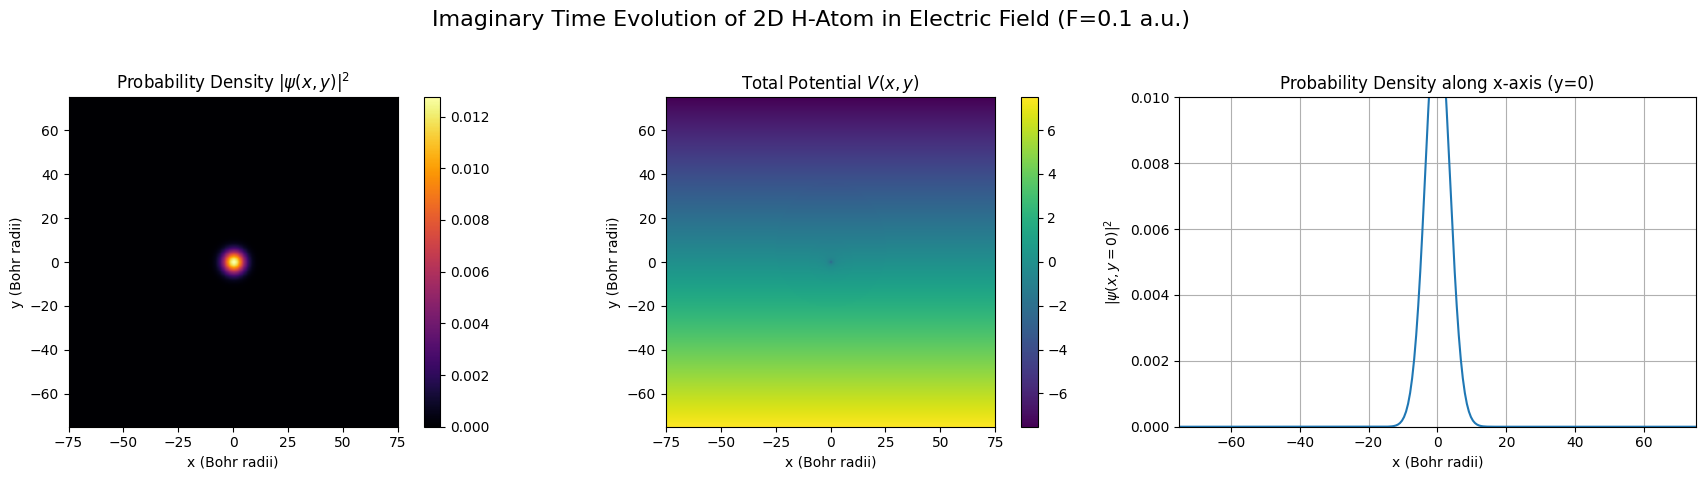

Starting Imaginary Time Evolution...
Step 100/1000
Step 200/1000
Step 300/1000
Step 400/1000
Step 500/1000
Step 600/1000
Step 700/1000
Step 800/1000
Step 900/1000
Step 1000/1000
Evolution complete.

--- Final Ground State Properties ---
Final Energy: -6.913452 Hartrees
  <T> = 0.384943 Hartrees
  <V> = -7.298395 Hartrees


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftshift, fftfreq

# --- Simulation Parameters ---
# Grid parameters
N = 256          # Number of grid points per dimension (must be a power of 2 for FFT efficiency)
L = 150.0        # Physical size of the grid in Bohr radii (a_0)

# Physics parameters (in atomic units)
F = 0.1         # Electric field strength. Set to 0 for no field.

# Imaginary Time Evolution parameters
dt = 0.05        # Imaginary time step (dτ)
n_steps = 1000   # Total number of evolution steps
plot_every = 100 # How often to update the plot

# --- Setup the Simulation Grid ---
# Create spatial grid
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x, y, indexing='ij')

# Create momentum space grid (k-space)
kx = fftfreq(N, d=L/N) * 2 * np.pi
ky = fftfreq(N, d=L/N) * 2 * np.pi
Kx, Ky = np.meshgrid(kx, ky, indexing='ij')
K2 = Kx**2 + Ky**2 # k^2 = kx^2 + ky^2

# --- Define the Potentials and Operators ---
# Coulomb potential V = -1/r. Add a small softening parameter to avoid singularity at r=0.
rho = np.sqrt(X**2 + Y**2)
V_coulomb = -1.0 / np.sqrt(rho**2 + 0.1)

# Stark effect potential V_stark = -F*x
V_stark = -F * X

# Total potential energy
V_total = V_coulomb + V_stark

# Kinetic energy operator in momentum space: T = p^2/2m = ħ^2 k^2 / 2m -> k^2/2 in a.u.
T_k = 0.5 * K2

# --- Define Evolution Operators for Split-Operator Method ---
# exp(-V*dt) - Note: In split-step, we apply V for a full dt
exp_V = np.exp(-V_total * dt)
# exp(-T*dt/2) - T is applied for two half-steps
exp_T_half = np.exp(-T_k * dt * 0.5)

# --- Initial Wavefunction ---
# Start with a simple 2D Gaussian as our initial guess.
# It doesn't need to be the right answer, just a non-zero overlap with the ground state.
sigma = 5.0
psi = np.exp(-(X**2 + Y**2) / (2 * sigma**2))

# Normalize the initial wavefunction
# The integration element is dx*dy = (L/N)*(L/N)
dx = L/N
norm_factor = np.sqrt(np.sum(np.abs(psi)**2) * dx**2)
psi /= norm_factor

# --- Visualization Setup ---
plt.ion() # Turn on interactive mode for plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Imaginary Time Evolution of 2D H-Atom in Electric Field (F={F} a.u.)', fontsize=16)

# Plot 1: Probability Density |ψ(x,y)|²
im_prob = axes[0].imshow(np.abs(psi)**2, extent=(-L/2, L/2, -L/2, L/2), cmap='inferno', origin='lower')
axes[0].set_title('Probability Density $|\psi(x,y)|^2$')
axes[0].set_xlabel('x (Bohr radii)')
axes[0].set_ylabel('y (Bohr radii)')
fig.colorbar(im_prob, ax=axes[0])

# Plot 2: Total Potential V(x,y)
im_pot = axes[1].imshow(V_total, extent=(-L/2, L/2, -L/2, L/2), cmap='viridis', origin='lower')
axes[1].set_title('Total Potential $V(x,y)$')
axes[1].set_xlabel('x (Bohr radii)')
axes[1].set_ylabel('y (Bohr radii)')
fig.colorbar(im_pot, ax=axes[1])

# Plot 3: 1D Wavefunction slice along x-axis
line_psi, = axes[2].plot(x, np.abs(psi[N//2, :])**2)
axes[2].set_title('Probability Density along x-axis (y=0)')
axes[2].set_xlabel('x (Bohr radii)')
axes[2].set_ylabel('$|\psi(x, y=0)|^2$')
axes[2].grid(True)
axes[2].set_xlim(-L/2, L/2)
axes[2].set_ylim(0, 0.01) # Initial guess for y-limit

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- Main Imaginary Time Evolution Loop ---
print("Starting Imaginary Time Evolution...")
for i in range(n_steps):
    # 1. First half-step in momentum space (evolution under T)
    psi_k = fft2(psi)
    psi_k *= exp_T_half
    psi = ifft2(psi_k)

    # 2. Full step in real space (evolution under V)
    psi *= exp_V

    # 3. Second half-step in momentum space (evolution under T)
    psi_k = fft2(psi)
    psi_k *= exp_T_half
    psi = ifft2(psi_k)

    # 4. Normalize the wavefunction at every step
    # This is crucial as the total probability is not conserved in imaginary time
    norm_factor = np.sqrt(np.sum(np.abs(psi)**2) * dx**2)
    psi /= norm_factor

    # --- Update Plots periodically ---
    if (i + 1) % plot_every == 0:
        print(f"Step {i+1}/{n_steps}")

        prob_density = np.abs(psi)**2
        im_prob.set_data(prob_density)
        im_prob.set_clim(0, np.max(prob_density))

        slice_data = prob_density[:, N//2]
        line_psi.set_ydata(slice_data)
        axes[2].set_ylim(0, np.max(slice_data) * 1.1)

        fig.canvas.draw()
        fig.canvas.flush_events()

print("Evolution complete.")
plt.ioff() # Turn off interactive mode

# Keep the final plot window open
plt.show()

# --- Final Energy Calculation (optional but recommended) ---
# Calculate the final energy <E> = <ψ|H|ψ> = <T> + <V>
# <V>
V_expectation = np.sum(np.conj(psi) * V_total * psi).real * dx**2
# <T>
psi_k = fft2(psi)
T_expectation = np.sum(np.conj(psi_k) * T_k * psi_k).real * (1.0 / N**2)

total_energy = V_expectation + T_expectation
print(f"\n--- Final Ground State Properties ---")
print(f"Final Energy: {total_energy:.6f} Hartrees")
print(f"  <T> = {T_expectation:.6f} Hartrees")
print(f"  <V> = {V_expectation:.6f} Hartrees")

# For F=0, the analytical 2D ground state energy is -2.0 Hartrees.
# Numerical results will be close but slightly higher due to grid discretization and potential softening.


In [ ]:
dipole_moment = np.sum(np.conj(psi) * X * psi).real * dx**2
print(f"Induced Dipole Moment: {dipole_moment:.6f} a.u.")

Induced Dipole Moment: 0.022443 a.u.


In [ ]:
# Stark Effect Simulation for 2D Hydrogen
# Physics intuition behind the code:
# We're finding how an electric field affects a hydrogen atom by:
# 1. Simulating quantum states using imaginary time evolution
# 2. Gradually increasing electric field strength
# 3. Tracking energy shifts and induced dipole moments

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftfreq
from tqdm import tqdm  # For progress visualization

def find_ground_state(F, N, L, dt, n_steps, initial_psi=None, show_plots=False):
    """
    Finds the quantum ground state for a given electric field strength F.

    Uses imaginary time propagation to evolve toward lowest energy state.
    If initial_psi is provided, uses it as starting point (helps convergence).
    """
    # Setup our spatial grid and momentum space
    x = np.linspace(-L/2, L/2, N)
    y = np.linspace(-L/2, L/2, N)
    X, Y = np.meshgrid(x, y, indexing='ij')
    dx = L/N

    # Momentum space setup for kinetic energy operator
    kx = 2 * np.pi * fftfreq(N, d=dx)
    ky = 2 * np.pi * fftfreq(N, d=dy)
    KX, KY = np.meshgrid(kx, ky)
    K2 = KX**2 + KY**2  # k^2 for kinetic energy operator
    T_term = np.exp(-K2 * dt / 2)  # Kinetic operator (constant)

    # Energy calculation function
    def compute_energy(psi, V):
        psi_k = fft2(psi)
        T_psi = ifft2(0.5 * K2 * psi_k)  # Kinetic energy: (1/2) k^2 psi
        H_psi = T_psi + V * psi          # H psi = T psi + V psi
        energy = np.sum(np.conj(psi) * H_psi) * dx * dy
        return energy.real

    # Function for imaginary time propagation
    def compute_ground_state(E_field, max_steps=5000):
        # Update potential with current E_field
        V = -1 / np.sqrt(r**2 + eps**2) + E_field * X
        V_term_base = np.exp(-V * dt / 2)  # Potential operator (depends on E_field)

        # Initialize wave function
        psi = psi_initial.copy()
        prev_energy = float('inf')

        # Imaginary time evolution
        for step in range(max_steps):
            # Apply half potential step
            psi *= V_term_base

            # FFT to momentum space and apply kinetic step
            psi_k = fft2(psi)
            psi_k *= T_term
            psi = ifft2(psi_k)

            # Apply second half potential step
            psi *= V_term_base

            # Normalize wave function
            norm = np.sum(np.abs(psi)**2) * dx * dy
            psi /= np.sqrt(norm)

            # Check convergence every 100 steps
            if step % 100 == 0:
                energy = compute_energy(psi, V)
                if abs(prev_energy - energy) < energy_tolerance and step > 100:
                    break
                prev_energy = energy

        # Final energy calculation
        energy = compute_energy(psi, V)
        return energy

    # Electric field values to study Stark effect
    E_field_list = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1]
    energies = []

    # Compute ground state energies for each E_field
    for E_val in E_field_list:
        energy = compute_ground_state(E_val)
        energies.append(energy)
        print(f"E_field = {E_val:.2f}, Ground State Energy = {energy:.6f}")

    # Quadratic Stark effect analysis
    E_squared = np.array(E_field_list)**2

    # Quadratic fit: energy = a + b * E^2
    A = np.vstack([E_squared, np.ones(len(E_squared))]).T
    b, a = np.linalg.lstsq(A, energies, rcond=None)[0]

    # Generate points for quadratic fit curve
    E_squared_fit = np.linspace(0, 0.01, 100)
    energy_fit = a + b * E_squared_fit

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True) # Share y axis for easier comparison
    fig.suptitle('Stark Effect in 2D Hydrogen Atom', fontsize=16, fontweight='bold') # Overall title

    # Plot 1: Energy vs Electric Field
    ax1.plot(E_field_list, energies, 'bo-', linewidth=2.5, markersize=8, label='Computed') # Increased linewidth and markersize
    ax1.set_xlabel('Electric Field Strength (E_field)', fontsize=14, fontweight='bold') # Make xlabel bold and larger
    ax1.set_ylabel('Ground State Energy', fontsize=14, fontweight='bold') # Make ylabel bold and larger
    ax1.set_title('(a) Stark Effect: Energy vs E_field', fontsize=16, fontweight='bold') # Make title bold and larger, add (a)
    ax1.grid(True)

    # Plot 2: Energy vs E_field Squared with Quadratic Fit
    ax2.plot(E_squared, energies, 'ro', markersize=8, label='Computed') # Increased markersize
    ax2.plot(E_squared_fit, energy_fit, 'b-', linewidth=2.5, # Increased linewidth
             label=f'Fit: y = {a:.4f} + {b:.2f}x')
    ax2.set_xlabel('Electric Field Squared (E_field$^2$)', fontsize=14, fontweight='bold') # Make xlabel bold and larger
    ax2.set_title('(b) Quadratic Stark Effect', fontsize=16, fontweight='bold') # Make title bold and larger, add (b)
    ax2.legend(prop={'weight': 'bold', 'size': 12}) # Make legend text bold and increased size
    ax2.grid(True)

    # Make axes lines and tick labels bold for both subplots
    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_linewidth(2.0) # Make spine lines thicker
            spine.set_edgecolor('black') # Ensure spine lines are black

        # Tick labels should not be bold as per user request
        # for tick in ax.get_xticklabels():
        #     tick.set_weight('bold')
        # for tick in ax.get_yticklabels():
        #     tick.set_weight('bold')


    plt.tight_layout()
    plt.savefig('stark_effect_analysis.png')
    plt.show()

    # Print quadratic Stark coefficient
    print(f"\nQuadratic Stark coefficient: {b:.4f} (energy shift per E_field^2)")

<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:78: SyntaxWarning: invalid escape sequence '\p'
<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:78: SyntaxWarning: invalid escape sequence '\p'
<>:80: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-212738397.py:56: SyntaxWarning: invalid escape sequence '\p'
  axes[0].set_title('2D Probability Density $|\psi(x,y)|^2$', fontweight='bold')
/tmp/ipython-input-212738397.py:78: SyntaxWarning: invalid escape sequence '\p'
  axes[2].set_ylabel('Probability Density $|\psi|^2$', color='crimson', fontweight='bold')
/tmp/ipython-input-212738397.py:80: SyntaxWarning: invalid escape sequence '\p'
  line_psi_lin, = axes[2].plot(x, prob_density[:, N//2], color='crimson', label='$|\psi(x,y=0)|^2$', linewidth=2.5) # Apply line width


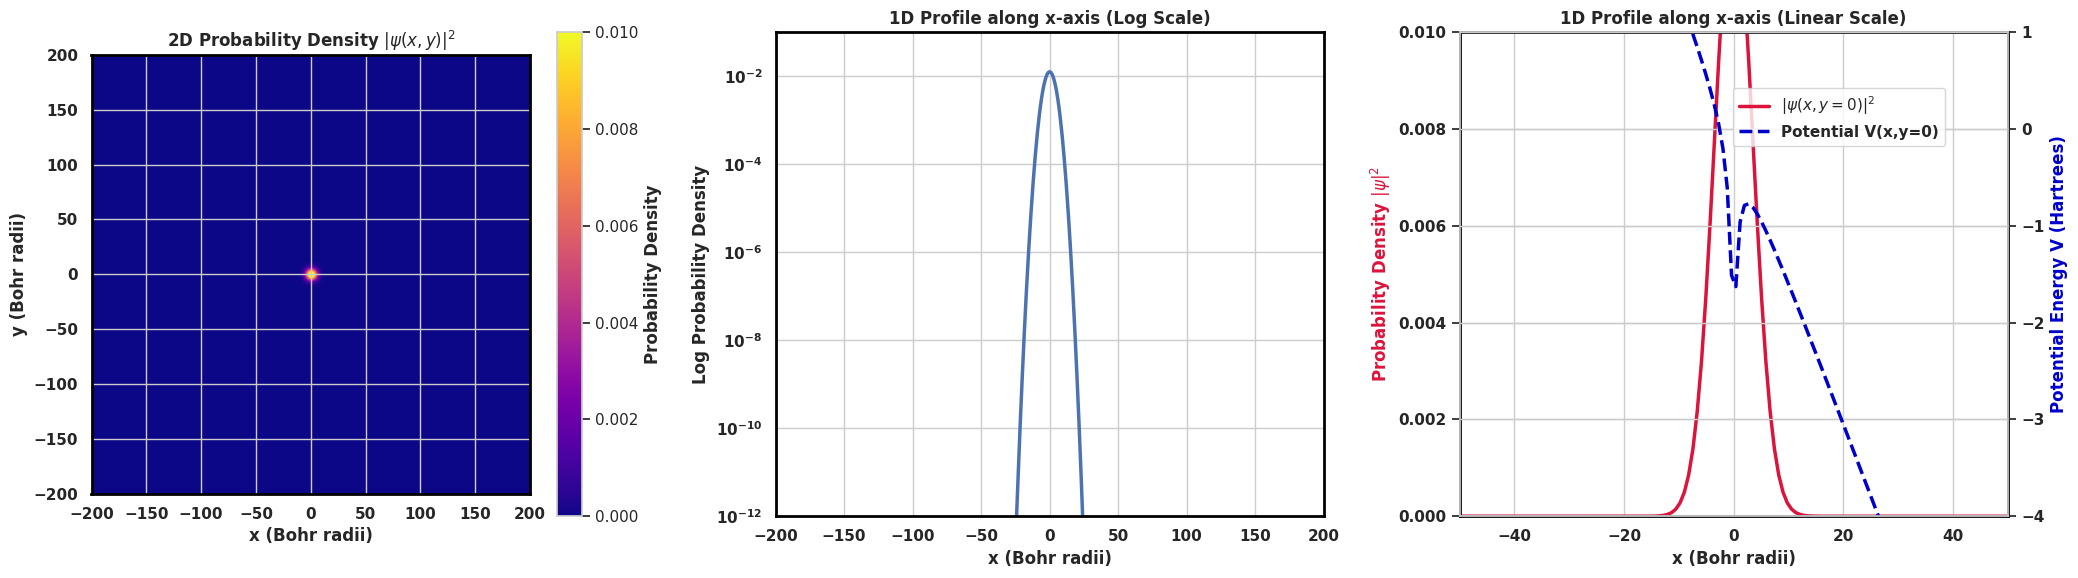

Starting Imaginary Time Evolution for strong field...
Step 100/10000
Step 200/10000
Step 300/10000
Step 400/10000
Step 500/10000
Step 600/10000
Step 700/10000
Step 800/10000
Step 900/10000
Step 1000/10000
Step 1100/10000
Step 1200/10000
Step 1300/10000
Step 1400/10000
Step 1500/10000
Step 1600/10000
Step 1700/10000
Step 1800/10000
Step 1900/10000
Step 2000/10000
Step 2100/10000
Step 2200/10000
Step 2300/10000
Step 2400/10000
Step 2500/10000
Step 2600/10000
Step 2700/10000
Step 2800/10000
Step 2900/10000
Step 3000/10000
Step 3100/10000
Step 3200/10000
Step 3300/10000
Step 3400/10000
Step 3500/10000
Step 3600/10000
Step 3700/10000
Step 3800/10000
Step 3900/10000
Step 4000/10000
Step 4100/10000
Step 4200/10000
Step 4300/10000
Step 4400/10000
Step 4500/10000
Step 4600/10000
Step 4700/10000
Step 4800/10000
Step 4900/10000
Step 5000/10000
Step 5100/10000
Step 5200/10000
Step 5300/10000
Step 5400/10000
Step 5500/10000
Step 5600/10000
Step 5700/10000
Step 5800/10000
Step 5900/10000
Step 6000/1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftfreq
import seaborn as sns # Import seaborn for styling

# --- Simulation Parameters ---
# Grid parameters
N = 512          # Increased resolution for more accuracy
L = 400.0        # Larger box to give the electron room to escape

# Physics parameters (in atomic units)
F = 0.15         # A strong electric field strength

# Imaginary Time Evolution parameters
dt = 0.05        # Imaginary time step (dτ)
n_steps = 10000   # More steps to converge on the quasi-bound state
plot_every = 100 # How often to update the plot

# --- Setup the Simulation Grid ---
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x, y, indexing='ij')
dx = L/N

kx = fftfreq(N, d=dx) * 2 * np.pi
ky = fftfreq(N, d=dx) * 2 * np.pi
Kx, Ky = np.meshgrid(kx, ky, indexing='ij')
K2 = Kx**2 + Ky**2

# --- Define the Potentials and Operators ---
rho = np.sqrt(X**2 + Y**2)
V_coulomb = -1.0 / np.sqrt(rho**2 + 0.1)
V_stark = -F * X
V_total = V_coulomb + V_stark
T_k = 0.5 * K2

exp_V = np.exp(-V_total * dt)
exp_T_half = np.exp(-T_k * dt * 0.5)

# --- Initial Wavefunction ---
psi = np.exp(-(X**2 + Y**2) / (2 * 5.0**2))
psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx**2)

# --- Visualization Setup ---
plt.ion()
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
# fig.suptitle(f'Strong-Field Stark Effect (F={F} a.u.) - Visualizing Tunneling', fontsize=16, fontweight='bold') # Removed suptitle

# Set seaborn style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 14}) # Set base font size

# Plot 1: 2D Probability Density |ψ(x,y)|²
prob_density = np.abs(psi)**2
im_prob = axes[0].imshow(prob_density, extent=(-L/2, L/2, -L/2, L/2), cmap='plasma', origin='lower', norm=plt.Normalize(0, 0.01)) # Changed cmap to 'plasma'
axes[0].set_title('2D Probability Density $|\psi(x,y)|^2$', fontweight='bold')
axes[0].set_xlabel('x (Bohr radii)', fontweight='bold')
axes[0].set_ylabel('y (Bohr radii)', fontweight='bold')
# Make colorbar label bold
cbar1 = fig.colorbar(im_prob, ax=axes[0])
cbar1.set_label('Probability Density', fontweight='bold')


# Plot 3: 1D Wavefunction (Logarithmic Scale) - KEY PLOT FOR TUNNELING
axes[1].set_title('1D Profile along x-axis (Log Scale)', fontweight='bold')
axes[1].set_xlabel('x (Bohr radii)', fontweight='bold')
axes[1].set_ylabel('Log Probability Density', fontweight='bold')
axes[1].grid(True)
line_psi_log, = axes[1].plot(x, prob_density[:, N//2], linewidth=2.5) # Apply line width
axes[1].set_yscale('log')
axes[1].set_xlim(-L/2, L/2)
axes[1].set_ylim(1e-12, 1e-1)


# Plot 2: 1D Potential and Wavefunction (Linear Scale)
axes[2].set_title('1D Profile along x-axis (Linear Scale)', fontweight='bold')
axes[2].set_xlabel('x (Bohr radii)', fontweight='bold')
axes[2].set_ylabel('Probability Density $|\psi|^2$', color='crimson', fontweight='bold')
axes[2].grid(True)
line_psi_lin, = axes[2].plot(x, prob_density[:, N//2], color='crimson', label='$|\psi(x,y=0)|^2$', linewidth=2.5) # Apply line width
ax2_twin = axes[2].twinx()
ax2_twin.set_ylabel('Potential Energy V (Hartrees)', color='mediumblue', fontweight='bold')
line_pot, = ax2_twin.plot(x, V_total[:, N//2], color='mediumblue', linestyle='--', label='Potential V(x,y=0)', linewidth=2.5) # Apply line width
axes[2].set_xlim(-50, 50)
axes[2].set_ylim(0, 0.01)
ax2_twin.set_ylim(-4, 1)
fig.legend(loc="upper right", bbox_to_anchor=(0.9,0.9), bbox_transform=axes[2].transAxes, prop={'weight': 'bold'}) # Make legend text bold


# Make axes lines and tick labels bold
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(2.0) # Make spine lines thicker
        spine.set_edgecolor('black') # Ensure spine lines are black

    # Make tick labels bold
    for tick in ax.get_xticklabels():
        tick.set_weight('bold')
    for tick in ax.get_yticklabels():
        tick.set_weight('bold')


# Apply bolding to the twin axis tick labels as well
for tick in ax2_twin.get_yticklabels():
    tick.set_weight('bold')


plt.tight_layout()
plt.show()

# --- Main Imaginary Time Evolution Loop ---
print("Starting Imaginary Time Evolution for strong field...")
for i in range(n_steps):
    psi_k = fft2(psi)
    psi_k *= exp_T_half
    psi = ifft2(psi_k)

    psi *= exp_V

    psi_k = fft2(psi)
    psi_k *= exp_T_half
    psi = ifft2(psi_k)

    psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx**2)

    # --- Update Plots periodically ---
    if (i + 1) % plot_every == 0:
        print(f"Step {i+1}/{n_steps}")
        prob_density = np.abs(psi)**2

        im_prob.set_data(prob_density)
        im_prob.set_clim(0, np.max(prob_density))

        slice_data = prob_density[:, N//2]
        line_psi_log.set_ydata(slice_data)
        line_psi_lin.set_ydata(slice_data)
        axes[2].set_ylim(0, np.max(slice_data) * 1.1)

        fig.canvas.draw()
        fig.canvas.flush_events()

print("Evolution complete.")
plt.ioff()
plt.show()

Running 15 simulations for weak fields...
Simulations complete.


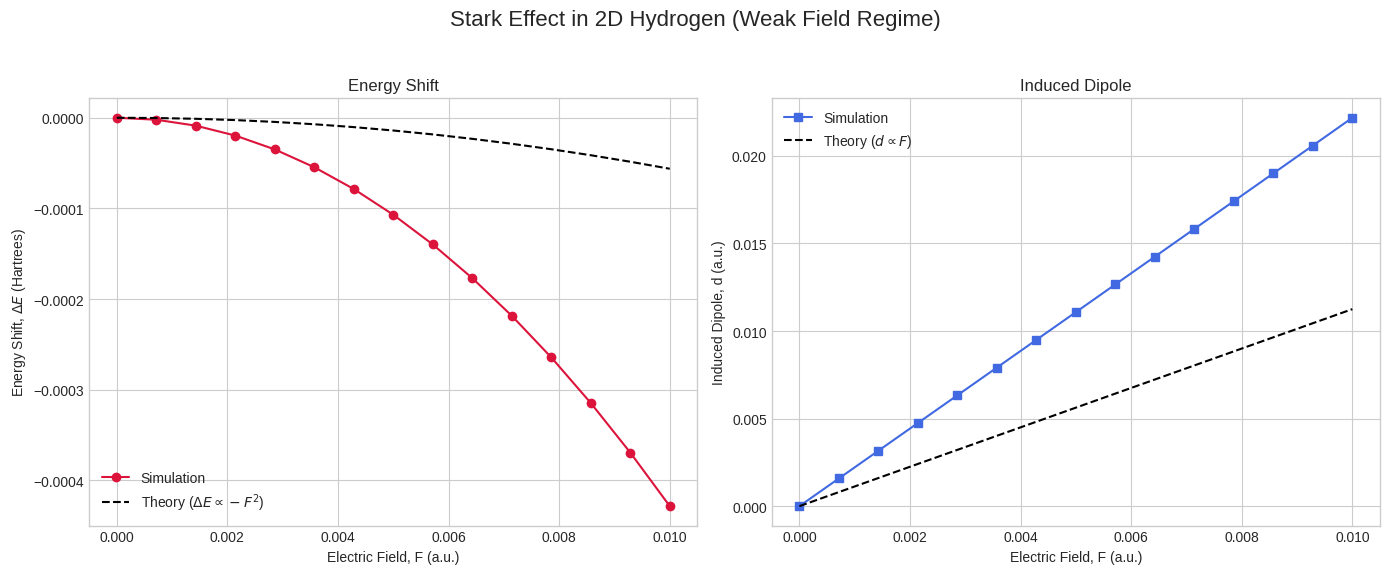

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftfreq

def find_ground_state(F, N, L, dt, n_steps):
    """Finds the ground state energy and dipole for a 2D H-atom in an electric field."""
    # --- Setup Grids ---
    x = np.linspace(-L/2, L/2, N)
    X, Y = np.meshgrid(x, x, indexing='ij')
    dx = x[1] - x[0]

    kx = fftfreq(N, d=dx) * 2 * np.pi
    Kx, Ky = np.meshgrid(kx, kx, indexing='ij')
    K2 = Kx**2 + Ky**2

    # --- Define Operators ---
    V = -1.0 / np.sqrt(X**2 + Y**2 + 0.1) - F * X  # Softened Coulomb + Stark
    T_k = 0.5 * K2
    exp_V = np.exp(-V * dt)
    exp_T_half = np.exp(-T_k * dt * 0.5)

    # --- Initial Wavefunction (Gaussian) ---
    psi = np.exp(-(X**2 + Y**2) / 50.0) # 2 * 5.0**2 = 50
    psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx**2)

    # --- Imaginary Time Evolution Loop ---
    for _ in range(n_steps):
        # Split-Operator Method
        psi = ifft2(fft2(psi) * exp_T_half)
        psi *= exp_V
        psi = ifft2(fft2(psi) * exp_T_half)
        # Renormalize
        psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx**2)

    # --- Final Calculations ---
    psi_k = fft2(psi)
    energy = (np.sum(np.conj(psi_k) * T_k * psi_k).real / N**2) + \
             (np.sum(np.conj(psi) * V * psi).real * dx**2)
    dipole = np.sum(np.conj(psi) * X * psi).real * dx**2

    return energy, dipole

# --- Main Simulation ---
N, L, dt, n_steps = 256, 150.0, 0.05, 1000
F_values = np.linspace(0, 0.01, 15)

# Run simulations using a list comprehension
print(f"Running {len(F_values)} simulations for weak fields...")
results = [find_ground_state(F, N, L, dt, n_steps) for F in F_values]
energies, dipoles = np.array(results).T
print("Simulations complete.")

# --- Plotting ---
alpha = 9.0 / 8.0  # Theoretical 2D polarizability
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Stark Effect in 2D Hydrogen (Weak Field Regime)', fontsize=16)

# Plot 1: Energy Shift
ax1.plot(F_values, energies - energies[0], 'o-', c='crimson', label='Simulation')
ax1.plot(F_values, -0.5 * alpha * F_values**2, '--k', label='Theory ($\Delta E \propto -F^2$)')
ax1.set(xlabel='Electric Field, F (a.u.)', ylabel='Energy Shift, $\Delta E$ (Hartrees)', title='Energy Shift')

# Plot 2: Induced Dipole
ax2.plot(F_values, dipoles, 's-', c='royalblue', label='Simulation')
ax2.plot(F_values, alpha * F_values, '--k', label='Theory ($d \propto F$)')
ax2.set(xlabel='Electric Field, F (a.u.)', ylabel='Induced Dipole, d (a.u.)', title='Induced Dipole')

# Final touches for both plots
for ax in (ax1, ax2):
    ax.legend()
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<>:54: SyntaxWarning: invalid escape sequence '\l'
<>:73: SyntaxWarning: invalid escape sequence '\p'
<>:75: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\l'
<>:73: SyntaxWarning: invalid escape sequence '\p'
<>:75: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-3908661110.py:54: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_title('2D Log Probability Density $\log_{10}|\psi|^2$', fontweight='bold')
/tmp/ipython-input-3908661110.py:73: SyntaxWarning: invalid escape sequence '\p'
  axes[2].set_ylabel('Probability Density $|\psi|^2$', color='crimson', fontweight='bold')
/tmp/ipython-input-3908661110.py:75: SyntaxWarning: invalid escape sequence '\p'
  line_psi_lin, = axes[2].plot(x, prob_density[:, N//2], color='crimson', label='$|\psi(x,y=0)|^2$', linewidth=2.5) # Apply line width
/tmp/ipython-input-3908661110.py:53: RuntimeWarning: divide by zero encountered in log10
  im_prob = axes[0].imshow(np.log10(prob_densit

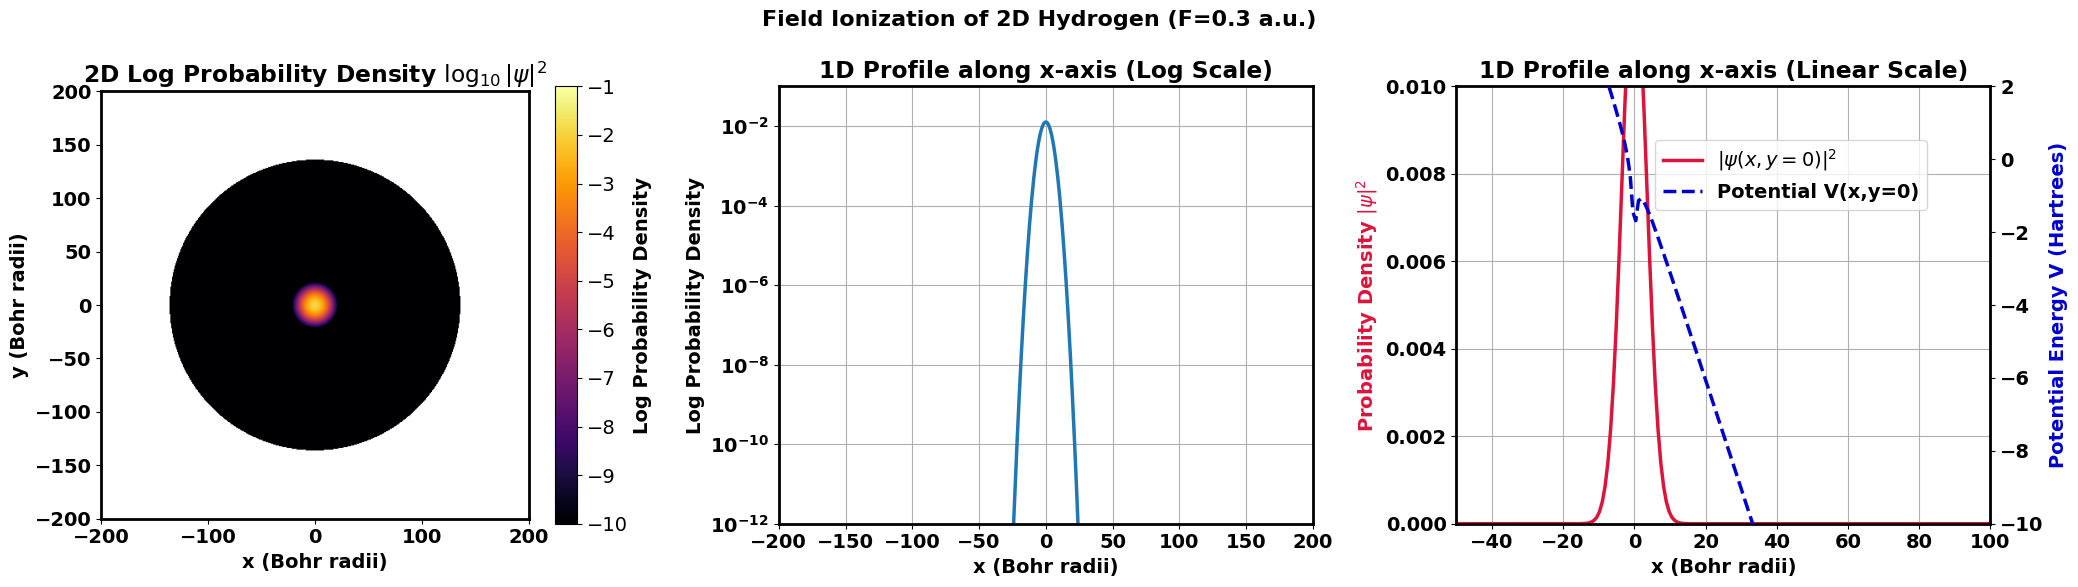

Starting simulation for extreme field...
Step 100/2000
Step 200/2000
Step 300/2000
Step 400/2000
Step 500/2000
Step 600/2000
Step 700/2000
Step 800/2000
Step 900/2000
Step 1000/2000
Step 1100/2000
Step 1200/2000
Step 1300/2000
Step 1400/2000
Step 1500/2000
Step 1600/2000
Step 1700/2000
Step 1800/2000
Step 1900/2000
Step 2000/2000
Evolution complete.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftfreq

# --- Simulation Parameters ---
# Grid parameters
N = 512          # High resolution
L = 400.0        # Large box to capture the escaping electron

# Physics parameters (in atomic units)
F = 0.30         # An extremely strong electric field to induce ionization

# Imaginary Time Evolution parameters
dt = 0.02        # Smaller time step for stability with the strong field
n_steps = 2000   # More steps to allow the state to settle
plot_every = 100 # How often to update the plot

# --- Setup the Simulation Grid ---
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x, y, indexing='ij')
dx = L/N

kx = fftfreq(N, d=dx) * 2 * np.pi
ky = fftfreq(N, d=dx) * 2 * np.pi
Kx, Ky = np.meshgrid(kx, ky, indexing='ij')
K2 = Kx**2 + Ky**2

# --- Define the Potentials and Operators ---
rho = np.sqrt(X**2 + Y**2)
V_coulomb = -1.0 / np.sqrt(rho**2 + 0.1)
V_stark = -F * X
V_total = V_coulomb + V_stark
T_k = 0.5 * K2

exp_V = np.exp(-V_total * dt)
exp_T_half = np.exp(-T_k * dt * 0.5)

# --- Initial Wavefunction ---
psi = np.exp(-(X**2 + Y**2) / (2 * 5.0**2))
psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx**2)

# --- Visualization Setup ---
plt.ion()
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(f'Field Ionization of 2D Hydrogen (F={F} a.u.)', fontsize=16, fontweight='bold')

# Set base font size
plt.rcParams.update({'font.size': 14})

# Plot 1: 2D Probability Density (Log Scale to see the leak)
prob_density = np.abs(psi)**2
im_prob = axes[0].imshow(np.log10(prob_density), extent=(-L/2, L/2, -L/2, L/2), cmap='inferno', origin='lower', vmin=-10, vmax=-1)
axes[0].set_title('2D Log Probability Density $\log_{10}|\psi|^2$', fontweight='bold')
axes[0].set_xlabel('x (Bohr radii)', fontweight='bold')
axes[0].set_ylabel('y (Bohr radii)', fontweight='bold')
cbar1 = fig.colorbar(im_prob, ax=axes[0])
cbar1.set_label('Log Probability Density', fontweight='bold') # Make colorbar label bold

# Plot 2: 1D Wavefunction (Logarithmic Scale) - KEY PLOT
axes[1].set_title('1D Profile along x-axis (Log Scale)', fontweight='bold')
axes[1].set_xlabel('x (Bohr radii)', fontweight='bold')
axes[1].set_ylabel('Log Probability Density', fontweight='bold')
axes[1].grid(True)
line_psi_log, = axes[1].plot(x, prob_density[:, N//2], linewidth=2.5) # Apply line width
axes[1].set_yscale('log')
axes[1].set_xlim(-L/2, L/2)
axes[1].set_ylim(1e-12, 1e-1)

# Plot 3: 1D Potential and Wavefunction (Linear Scale)
axes[2].set_title('1D Profile along x-axis (Linear Scale)', fontweight='bold')
axes[2].set_xlabel('x (Bohr radii)', fontweight='bold')
axes[2].set_ylabel('Probability Density $|\psi|^2$', color='crimson', fontweight='bold')
axes[2].grid(True)
line_psi_lin, = axes[2].plot(x, prob_density[:, N//2], color='crimson', label='$|\psi(x,y=0)|^2$', linewidth=2.5) # Apply line width
ax2_twin = axes[2].twinx()
ax2_twin.set_ylabel('Potential Energy V (Hartrees)', color='mediumblue', fontweight='bold')
line_pot, = ax2_twin.plot(x, V_total[:, N//2], color='mediumblue', linestyle='--', label='Potential V(x,y=0)', linewidth=2.5) # Apply line width
axes[2].set_xlim(-50, 100) # Extend x-axis to see tunneling
axes[2].set_ylim(0, 0.01)
ax2_twin.set_ylim(-10, 2)
fig.legend(loc="upper right", bbox_to_anchor=(0.9,0.9), bbox_transform=axes[2].transAxes, prop={'weight': 'bold'}) # Make legend text bold

# Make axes lines and tick labels bold
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(2.0) # Make spine lines thicker
        spine.set_edgecolor('black') # Ensure spine lines are black

    # Make tick labels bold
    for tick in ax.get_xticklabels():
        tick.set_weight('bold')
    for tick in ax.get_yticklabels():
        tick.set_weight('bold')

# Apply bolding to the twin axis tick labels as well
for tick in ax2_twin.get_yticklabels():
    tick.set_weight('bold')


plt.tight_layout()
plt.show()

# --- Main Imaginary Time Evolution Loop ---
print("Starting simulation for extreme field...")
for i in range(n_steps):
    psi_k = fft2(psi)
    psi_k *= exp_T_half
    psi = ifft2(psi_k)
    psi *= exp_V
    psi_k = fft2(psi)
    psi_k *= exp_T_half
    psi = ifft2(psi_k)
    psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx**2)

    if (i + 1) % plot_every == 0:
        print(f"Step {i+1}/{n_steps}")
        prob_density = np.abs(psi)**2

        im_prob.set_data(np.log10(prob_density))

        slice_data = prob_density[:, N//2]
        line_psi_log.set_ydata(slice_data)
        line_psi_lin.set_ydata(slice_data)
        axes[2].set_ylim(0, np.max(slice_data) * 1.1)

        fig.canvas.draw()
        fig.canvas.flush_events()

print("Evolution complete.")
plt.ioff()
plt.show()

Starting Imaginary Time Evolution...
Iteration 0: Energy = 1.464033, <x> = 0.000003
Iteration 2000: Energy = 1.098891, <x> = 0.011723
Iteration 4000: Energy = 0.873400, <x> = 0.035000
Iteration 6000: Energy = 0.713452, <x> = 0.069854
Iteration 8000: Energy = 0.588511, <x> = 0.115655
Iteration 10000: Energy = 0.471229, <x> = 0.235845
Iteration 12000: Energy = -3.704830, <x> = 19.380083
Iteration 14000: Energy = -3.868649, <x> = 19.612849
Iteration 16000: Energy = -3.968482, <x> = 19.676728
Iteration 18000: Energy = -4.044571, <x> = 19.719419
Iteration 20000: Energy = -4.104465, <x> = 19.749618
Iteration 22000: Energy = -4.153027, <x> = 19.772043
Iteration 24000: Energy = -4.193531, <x> = 19.789418
Iteration 26000: Energy = -4.228276, <x> = 19.803396
Iteration 28000: Energy = -4.258930, <x> = 19.815025
Iteration 30000: Energy = -4.286749, <x> = 19.824990
Iteration 32000: Energy = -4.312698, <x> = 19.833757
Iteration 34000: Energy = -4.337536, <x> = 19.841643
Iteration 36000: Energy = -4.

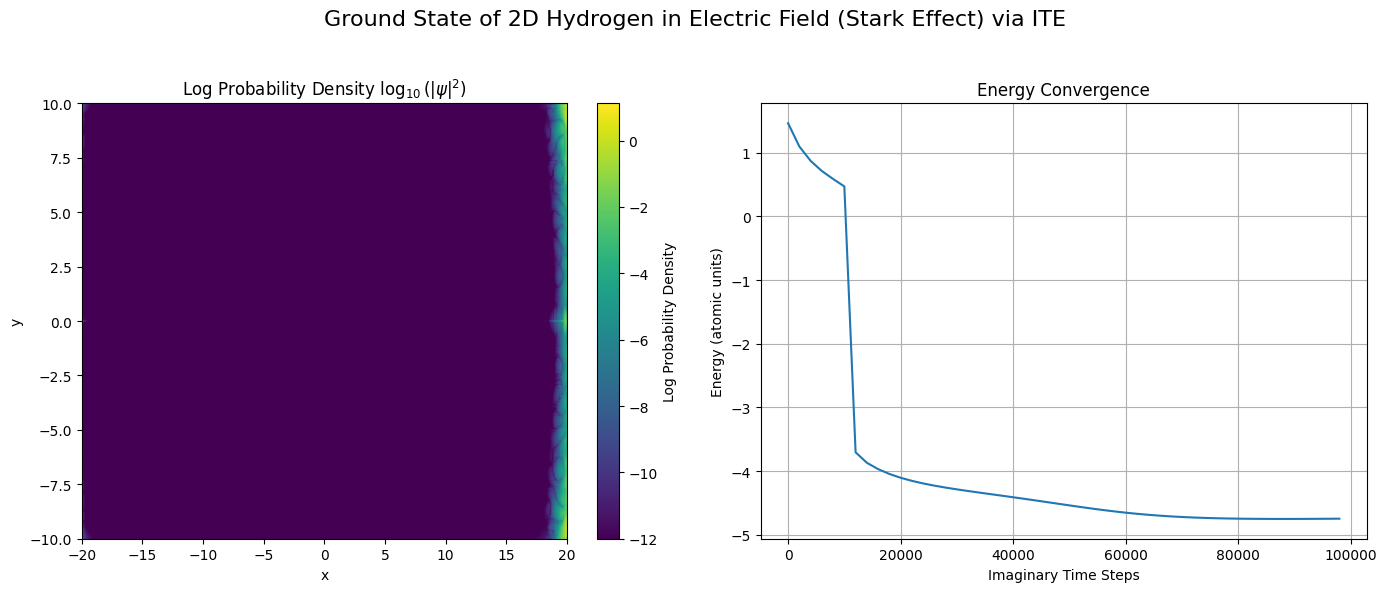

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Lx, Ly = 40.0, 20.0      # Domain size
Nx, Ny = 1024, 512       # Grid resolution
dx, dy = Lx / Nx, Ly / Ny # Grid spacing
x = np.linspace(-Lx/2, Lx/2, Nx)
y = np.linspace(-Ly/2, Ly/2, Ny)
X, Y = np.meshgrid(x, y, indexing='ij') # Cartesian coordinates
r = np.sqrt(X**2 + Y**2)                # Radial distance

# Regularized 2D Coulomb potential with Stark term
epsilon = dx             # Regularization parameter (grid spacing)
# --- CORRECTION 1: Use a negative E to match the rightward shift observed ---
E = -0.1                 # A negative E creates a force in the +x direction.

V = -np.log(r + epsilon) + E * X  # Attractive Coulomb + Stark potential

# Initial wavefunction: Gaussian centered near expected equilibrium
# A center of 0.0 is a safe, unbiased starting point.
initial_center_x = 0.0
psi = np.exp(-8 * ((X - initial_center_x)**2 + Y**2)) # Narrow Gaussian

# --- Helper function to calculate energy ---
def get_energy(psi, V_pot, dx, dy, K_sq, hbar=1.0, m=1.0):
    """Calculates the expectation value of the energy using the spectral kinetic energy."""
    potential_energy = np.sum(np.conj(psi) * V_pot * psi).real * dx * dy
    psi_k = np.fft.fft2(psi)
    kinetic_energy = np.sum((hbar**2 / (2 * m)) * K_sq * np.abs(psi_k)**2).real / (Nx * Ny)
    energy = kinetic_energy + potential_energy
    return energy

# Fourier space variables
kx = (2 * np.pi / Lx) * np.fft.fftfreq(Nx)
ky = (2 * np.pi / Ly) * np.fft.fftfreq(Ny)
KX, KY = np.meshgrid(kx, ky, indexing='ij')
K_sq = KX**2 + KY**2  # Kinetic energy term in Fourier space (k^2)

# --- CORRECTION 2 & 3: Adjust time step and total iterations ---
dt = 0.0005              # Time step: faster than 0.0001, but stable unlike 0.001
nt = 100000              # Number of iterations: increased to allow for full convergence

# Imaginary Time Evolution
print("Starting Imaginary Time Evolution...")
energies = [] # To store energy convergence

for i in range(nt):
    # Half-step in potential
    psi *= np.exp(-V * dt / 2)

    # Full-step in kinetic energy (Fourier space)
    psi_k = np.fft.fft2(psi)
    psi_k *= np.exp(-0.5 * K_sq * dt)
    psi = np.fft.ifft2(psi_k)

    # Half-step in potential
    psi *= np.exp(-V * dt / 2)

    # Normalize
    norm = np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)
    if norm == 0:
        print("Warning: Wavefunction norm is zero.")
        break
    psi /= norm

    # Track convergence (checking every 2000 steps now)
    if i % 2000 == 0:
        current_energy = get_energy(psi, V, dx, dy, K_sq)
        energies.append(current_energy)
        x_expect = np.sum(X * np.abs(psi)**2 * dx * dy)
        print(f"Iteration {i}: Energy = {current_energy:.6f}, <x> = {x_expect:.6f}")

print("\nFinished Imaginary Time Evolution.")

# Compute final expectation value of x
x_expectation = np.sum(X * np.abs(psi)**2 * dx * dy)
print(f"\nFinal <x> = {x_expectation:.6f}")
final_energy = get_energy(psi, V, dx, dy, K_sq)
print(f"Final calculated energy: {final_energy:.6f}")

# Plotting the final state and energy convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Ground State of 2D Hydrogen in Electric Field (Stark Effect) via ITE', fontsize=16)

# Plot final wavefunction
prob = np.abs(psi)**2
prob[prob < 1e-12] = 1e-12 # Avoid log(0)
im = ax1.imshow(np.log10(prob.T),
              extent=[-Lx/2, Lx/2, -Ly/2, Ly/2],
              cmap='viridis', aspect='auto', origin='lower')
ax1.set_title('Log Probability Density $\\log_{10}(|\\psi|^2)$')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
fig.colorbar(im, ax=ax1, label='Log Probability Density')

# Plot energy convergence
if energies:
    ax2.plot(np.arange(0, nt, 2000), energies)
    ax2.set_title('Energy Convergence')
    ax2.set_xlabel('Imaginary Time Steps')
    ax2.set_ylabel('Energy (atomic units)')
    ax2.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

<>:128: SyntaxWarning: invalid escape sequence '\p'
<>:128: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-1528020160.py:128: SyntaxWarning: invalid escape sequence '\p'
  axes[0].set_title('(a) Single-Electron Probability Density $|\phi|^2$', fontweight='bold')


--- Starting SCF Calculation ---
  SCF Step  1: Total Energy = -2.052881 Hartrees
  SCF Step  2: Total Energy = -2.063405 Hartrees
  SCF Step  3: Total Energy = -2.074209 Hartrees
  SCF Step  4: Total Energy = -2.089282 Hartrees
  SCF Step  5: Total Energy = -2.109917 Hartrees
  SCF Step  6: Total Energy = -2.130200 Hartrees
  SCF Step  7: Total Energy = -2.133266 Hartrees
  SCF Step  8: Total Energy = -2.119835 Hartrees
  SCF Step  9: Total Energy = -2.120472 Hartrees
  SCF Step 10: Total Energy = -2.138652 Hartrees
  SCF Step 11: Total Energy = -2.152351 Hartrees
  SCF Step 12: Total Energy = -2.155639 Hartrees
  SCF Step 13: Total Energy = -2.154894 Hartrees
  SCF Step 14: Total Energy = -2.154625 Hartrees
  SCF Step 15: Total Energy = -2.155551 Hartrees
  SCF Step 16: Total Energy = -2.156773 Hartrees
  SCF Step 17: Total Energy = -2.157467 Hartrees
  SCF Step 18: Total Energy = -2.157587 Hartrees
  SCF Step 19: Total Energy = -2.157586 Hartrees
  SCF Step 20: Total Energy = -2.157

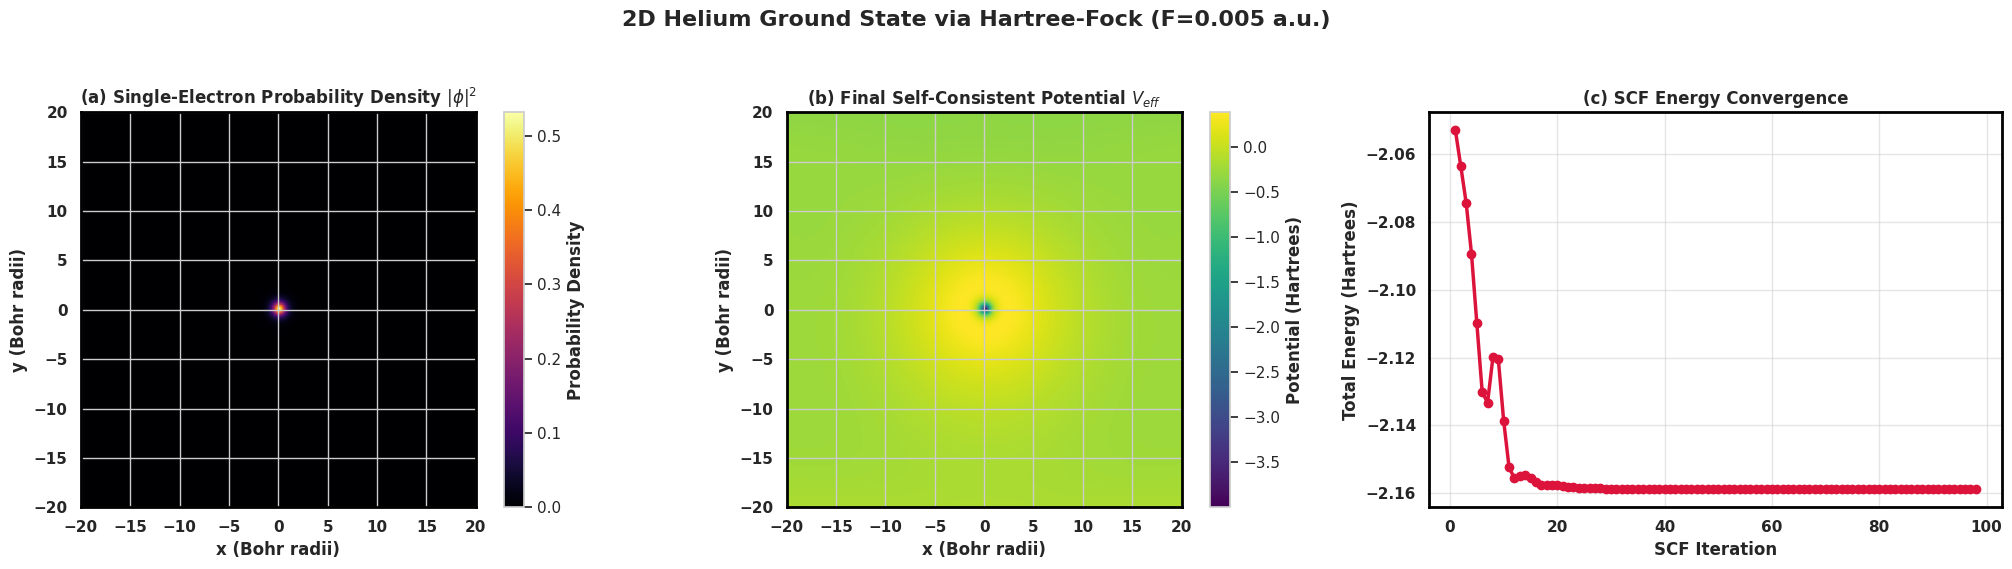

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftfreq
import seaborn as sns # Import seaborn for styling

def solve_helium_scf(params):
    """
    Finds the ground state of a 2D Helium atom in an electric field
    using the Hartree Self-Consistent Field (SCF) method.
    """
    F = params['field_strength']
    N = params['grid_points']
    L = params['grid_size']
    dt = params['time_step']
    n_steps_ite = params['inner_steps']
    n_steps_scf = params['max_scf_steps']
    tolerance = params['tolerance']

    # --- Setup Grids ---
    x = np.linspace(-L/2, L/2, N, endpoint=False)
    y = np.linspace(-L/2, L/2, N, endpoint=False)
    X, Y = np.meshgrid(x, y, indexing='ij')
    dx = L / N
    kx = fftfreq(N, d=dx) * 2 * np.pi
    ky = fftfreq(N, d=dx) * 2 * np.pi
    Kx, Ky = np.meshgrid(kx, ky, indexing='ij')
    K2 = Kx**2 + Ky**2

    # Avoid division by zero in K2 (at k=0)
    K2[0, 0] = 1.0  # Will be set to zero later where needed

    # --- Define Fixed Potentials ---
    Z = 2.0
    epsilon = 0.1  # Reduced softening parameter for a deeper potential
    V_nucleus = -Z / np.sqrt(X**2 + Y**2 + epsilon)
    V_stark = -F * X

    # --- Initial Guess for the orbital ---
    r = np.sqrt(X**2 + Y**2)
    phi = np.exp(-Z * r / 2.0)  # Hydrogen-like initial guess with effective charge Z
    phi /= np.sqrt(np.sum(np.abs(phi)**2) * dx**2)

    # --- Self-Consistent Field (SCF) Loop ---
    print("--- Starting SCF Calculation ---")
    last_total_energy = 0
    energy_history = []
    V_eff_old = np.zeros_like(X)

    for scf_step in range(n_steps_scf):
        charge_density_prev = np.abs(phi)**2
        V_hartree_prev_k = fft2(charge_density_prev)
        # Corrected Green's function for 2D
        with np.errstate(divide='ignore', invalid='ignore'):
             V_hartree_prev_k = (2 * np.pi / K2) * V_hartree_prev_k
        V_hartree_prev_k[0, 0] = 0  # Set DC component to zero
        V_hartree_prev = ifft2(V_hartree_prev_k).real

        # Define the effective potential using damping for stability
        V_eff_new = V_nucleus + V_stark + V_hartree_prev
        if scf_step > 0:
            damping_factor = 0.7  # Adjusted damping factor
            V_eff = damping_factor * V_eff_old + (1 - damping_factor) * V_eff_new
        else:
            V_eff = V_eff_new
        V_eff_old = V_eff

        # Find the NEW orbital by relaxing it in the effective potential
        exp_V_half = np.exp(-0.5 * V_eff * dt)
        exp_T_full = np.exp(-0.5 * K2 * dt)

        for _ in range(n_steps_ite):
            phi *= exp_V_half
            phi = ifft2(fft2(phi) * exp_T_full)
            phi *= exp_V_half
            phi /= np.sqrt(np.sum(np.abs(phi)**2) * dx**2)

        # Energy calculation
        # 1. Kinetic Energy for two electrons
        phi_k = fft2(phi)
        T_phi = ifft2(0.5 * K2 * phi_k)
        T_exp = np.sum(np.conj(phi) * T_phi).real * dx**2
        E_kinetic = 2 * T_exp

        # 2. Potential energy from nucleus and field for two electrons
        V_ext_exp = np.sum(np.abs(phi)**2 * (V_nucleus + V_stark)).real * dx**2
        E_external = 2 * V_ext_exp

        # 3. Electron-electron repulsion energy (calculated from the NEW density)
        charge_density_new = np.abs(phi)**2
        V_hartree_new_k = fft2(charge_density_new)
        # Corrected Green's function for 2D
        with np.errstate(divide='ignore', invalid='ignore'):
             V_hartree_new_k = (2 * np.pi / K2) * V_hartree_new_k
        V_hartree_new_k[0, 0] = 0  # Set DC component to zero
        V_hartree_new = ifft2(V_hartree_new_k).real
        E_repulsion = np.sum(charge_density_new * V_hartree_new).real * dx**2

        # 4. The true total energy
        total_energy = E_kinetic + E_external + E_repulsion
        energy_history.append(total_energy)
        print(f"  SCF Step {scf_step+1:2d}: Total Energy = {total_energy:.6f} Hartrees")

        if np.abs(total_energy - last_total_energy) < tolerance and scf_step > 0:
            print(f"\nConvergence reached in {scf_step+1} steps.")
            break
        last_total_energy = total_energy
    else:
        print("\nWarning: SCF did not converge to the desired tolerance.")

    results = { "orbital": phi, "energy": total_energy, "potential": V_eff,
                "energy_history": energy_history, "params": params }
    return results

def plot_results(results):
    """Generates plots for the final results."""
    phi, V_eff, energy_history = results["orbital"], results["potential"], results["energy_history"]
    F, L = results["params"]['field_strength'], results["params"]['grid_size']

    # Set seaborn style
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 14}) # Set base font size

    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    fig.suptitle(f'2D Helium Ground State via Hartree-Fock (F={F:.3f} a.u.)', fontsize=16, fontweight='bold')

    # Plot 1: Electron Density (a)
    im1 = axes[0].imshow(np.abs(phi)**2, cmap='inferno', extent=(-L/2, L/2, -L/2, L/2), origin='lower')
    axes[0].set_title('(a) Single-Electron Probability Density $|\phi|^2$', fontweight='bold')
    axes[0].set_xlabel('x (Bohr radii)', fontweight='bold')
    axes[0].set_ylabel('y (Bohr radii)', fontweight='bold')
    cbar1 = fig.colorbar(im1, ax=axes[0])
    cbar1.set_label('Probability Density', fontweight='bold')

    # Plot 2: Effective Potential (b)
    im2 = axes[1].imshow(np.clip(V_eff, np.min(V_eff), 1), cmap='viridis', extent=(-L/2, L/2, -L/2, L/2), origin='lower')
    axes[1].set_title('(b) Final Self-Consistent Potential $V_{eff}$', fontweight='bold')
    axes[1].set_xlabel('x (Bohr radii)', fontweight='bold')
    axes[1].set_ylabel('y (Bohr radii)', fontweight='bold') # Added y-label for consistency
    cbar2 = fig.colorbar(im2, ax=axes[1])
    cbar2.set_label('Potential (Hartrees)', fontweight='bold')

    # Plot 3: Energy Convergence (c)
    axes[2].plot(range(1, len(energy_history)+1), energy_history, 'o-', color='crimson', linewidth=2.5) # Increased line width
    axes[2].set_title('(c) SCF Energy Convergence', fontweight='bold')
    axes[2].set_xlabel('SCF Iteration', fontweight='bold')
    axes[2].set_ylabel('Total Energy (Hartrees)', fontweight='bold')
    axes[2].grid(True, alpha=0.5) # Added grid with some transparency

    # Make axes lines and tick labels bold for all subplots
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_linewidth(2.0) # Make spine lines thicker
            spine.set_edgecolor('black') # Ensure spine lines are black

        for tick in ax.get_xticklabels():
            tick.set_weight('bold')
        for tick in ax.get_yticklabels():
            tick.set_weight('bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjusted layout
    plt.show()

if __name__ == "__main__":
    sim_params = {
        'grid_points': 256,
        'grid_size': 40.0,
        'field_strength': 0.005,
        'time_step': 0.01,
        'inner_steps': 100,
        'max_scf_steps': 500,
        'tolerance': 1e-7,
    }
    final_results = solve_helium_scf(sim_params)
    print("\n--- Final Result ---")
    print(f"Converged Ground State Energy: {final_results['energy']:.6f} Hartrees")
    plot_results(final_results)

--- Starting 2D Helium Calculation ---
Cycle  1: Total Energy = -0.53926704 Ha
Cycle  2: Total Energy = -2.43105849 Ha
Cycle  3: Total Energy = -3.80545878 Ha
Cycle  4: Total Energy = -4.87379515 Ha
Cycle  5: Total Energy = -5.73459305 Ha
Cycle  6: Total Energy = -6.44966750 Ha
Cycle  7: Total Energy = -7.05885476 Ha
Cycle  8: Total Energy = -7.58835260 Ha
Cycle  9: Total Energy = -8.05597493 Ha
Cycle 10: Total Energy = -8.47427840 Ha
Cycle 11: Total Energy = -8.85240767 Ha
Cycle 12: Total Energy = -9.19722187 Ha
Cycle 13: Total Energy = -9.51407077 Ha
Cycle 14: Total Energy = -9.80753102 Ha
Cycle 15: Total Energy = -10.08223320 Ha
Cycle 16: Total Energy = -10.34324433 Ha
Cycle 17: Total Energy = -10.59482252 Ha
Cycle 18: Total Energy = -10.83738426 Ha
Cycle 19: Total Energy = -11.06542199 Ha
Cycle 20: Total Energy = -11.26997808 Ha
Cycle 21: Total Energy = -11.44470092 Ha
Cycle 22: Total Energy = -11.58997339 Ha
Cycle 23: Total Energy = -11.71216032 Ha
Cycle 24: Total Energy = -11.820

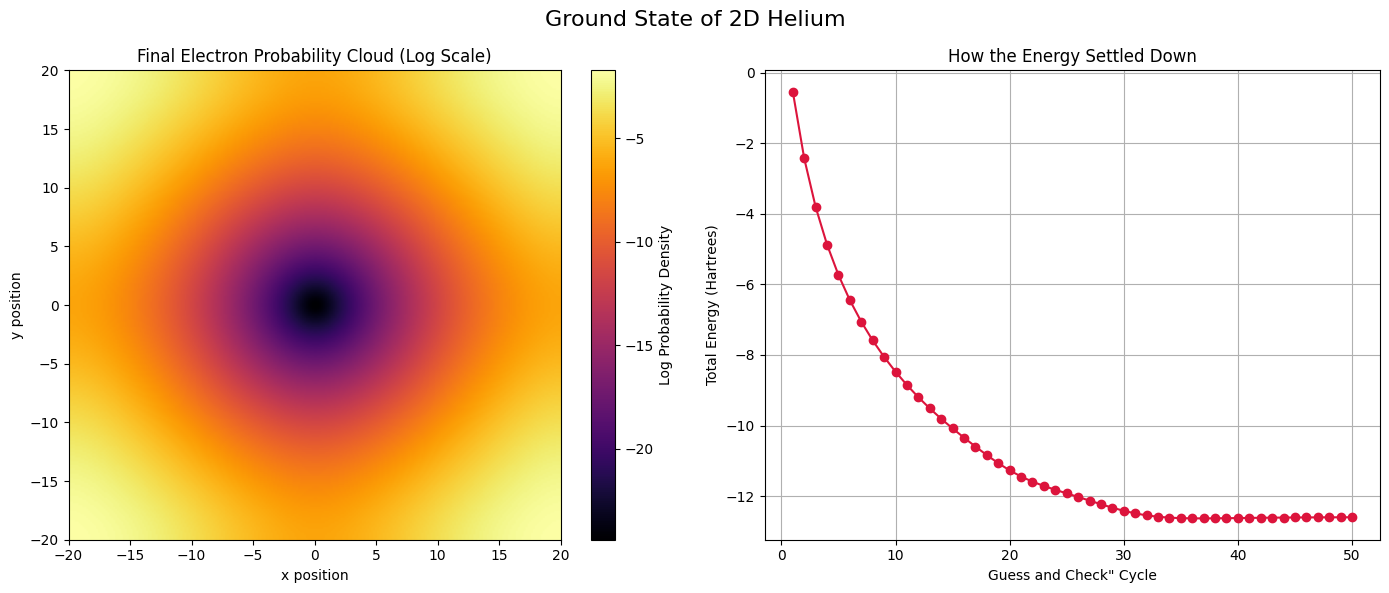


Final Ground State Energy = -12.59861723 Hartrees


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setting up our 2D world ---
box_width, box_height = 40.0, 40.0         # How big is our simulation box?
grid_points_x, grid_points_y = 256, 256   # How many points in our grid?
grid_spacing_x = box_width / grid_points_x
grid_spacing_y = box_height / grid_points_y

# Create coordinate points for every spot on our grid
x_axis = np.linspace(-box_width / 2, box_width / 2, grid_points_x)
y_axis = np.linspace(-box_height / 2, box_height / 2, grid_points_y)
x_coords, y_coords = np.meshgrid(x_axis, y_axis, indexing='ij')

# --- 2. Setting up Fourier Space ---
# Some calculations, like kinetic energy, are way easier in "Fourier space".
kx_wavevectors = 2 * np.pi * np.fft.fftfreq(grid_points_x, d=grid_spacing_x)
ky_wavevectors = 2 * np.pi * np.fft.fftfreq(grid_points_y, d=grid_spacing_y)
kx_grid, ky_grid = np.meshgrid(kx_wavevectors, ky_wavevectors, indexing='ij')

# The kinetic energy is proportional to k^2, so let's pre-calculate that.
k_squared = kx_grid**2 + ky_grid**2

# --- 3. Defining the "Forces" in Our World ---
nuclear_charge = 2.0  # For Helium, which has 2 protons.

# Potential from the nucleus. In 2D, this attraction is a log function, not 1/r.
distance_from_nucleus = np.sqrt(x_coords**2 + y_coords**2)
potential_smoothing = grid_spacing_x # A tiny value to prevent log(0) which is -infinity!
nuclear_potential = -nuclear_charge * np.log(distance_from_nucleus + potential_smoothing)
electric_field_strength = 0.0
electric_field_potential = electric_field_strength * x_coords

# --- 4. First Guess for the Electron Cloud ---
wavefunction = np.exp(-1.5 * (x_coords**2 + y_coords**2))

# "Normalize" the wavefunction.
total_probability = np.sum(np.abs(wavefunction)**2) * grid_spacing_x * grid_spacing_y
wavefunction /= np.sqrt(total_probability)

# --- 5. Simulation Controls ---
imaginary_time_step = 0.01   # How big of a "relaxing" step we take to find the lowest energy.
num_imaginary_steps = 50      # How many relaxing steps to take each cycle.
max_scf_iterations = 50       # Max number of "guess and check" cycles.
convergence_tolerance = 1e-8  # Stop when the energy is this stable.
damping_factor = 0.3          # How much to mix new/old results to keep things from oscillating.

# --- 6. The Main "Guess and Check" (SCF) Loop ---
print("--- Starting 2D Helium Calculation ---")
last_total_energy = 0
energy_history = []

# Initialize the potential that one electron feels.
effective_potential = np.copy(nuclear_potential)

for scf_cycle in range(max_scf_iterations):

    # Keep a copy of the potential from the last cycle for our damping step.
    old_effective_potential = np.copy(effective_potential)

    # --- Step A: Calculate Repulsion From the Other Electron ---
    # The "Hartree potential" is the repulsion one electron feels from the other's cloud.
    electron_density = np.abs(wavefunction)**2
    electron_density_fourier = np.fft.fft2(electron_density)

    # Solve for the potential in Fourier space.
    with np.errstate(divide='ignore', invalid='ignore'):
        hartree_potential_fourier = (2 * np.pi / np.sqrt(k_squared)) * electron_density_fourier
    hartree_potential_fourier[0, 0] = 0.0 # Handle the k=0 case to avoid division by zero.

    # Convert back to real space to get the potential we can use.
    hartree_potential = np.fft.ifft2(hartree_potential_fourier).real

    # --- Step B: Calculate the New Total "Force Field" ---
    new_effective_potential = nuclear_potential + electric_field_potential + hartree_potential

    # --- Step C: Damping for Stability (The Secret Sauce!) ---
    effective_potential = damping_factor * new_effective_potential + (1 - damping_factor) * old_effective_potential

    # --- Step D: Find the New, Better Electron Cloud ---
    for i in range(num_imaginary_steps):
        wavefunction *= np.exp(-effective_potential * imaginary_time_step / 2)
        wavefunction_fourier = np.fft.fft2(wavefunction)
        wavefunction_fourier *= np.exp(-k_squared * imaginary_time_step) # Kinetic part is easy in Fourier space!
        wavefunction = np.fft.ifft2(wavefunction_fourier)
        wavefunction *= np.exp(-effective_potential * imaginary_time_step / 2)
        wavefunction /= np.sqrt(np.sum(np.abs(wavefunction)**2) * grid_spacing_x * grid_spacing_y)

    # --- Step E: Calculate Energies and Check if We're Done ---
    wavefunction_fourier = np.fft.fft2(wavefunction)

    # Calculate the average kinetic and potential energy for a single electron.
    kinetic_energy_operator = np.fft.ifft2(k_squared * wavefunction_fourier)
    kinetic_energy = np.sum(np.conj(wavefunction) * kinetic_energy_operator).real * grid_spacing_x * grid_spacing_y
    potential_energy = np.sum(effective_potential * np.abs(wavefunction)**2).real * grid_spacing_x * grid_spacing_y
    single_electron_energy = kinetic_energy + potential_energy

    # The total energy isn't just 2 * single_electron_energy, because that double-counts
    electron_repulsion_energy = np.sum(hartree_potential * np.abs(wavefunction)**2).real * grid_spacing_x * grid_spacing_y
    total_energy = 2 * single_electron_energy - electron_repulsion_energy

    energy_history.append(total_energy)
    print(f"Cycle {scf_cycle+1:2d}: Total Energy = {total_energy:.8f} Ha")

    # Check for convergence.
    if abs(total_energy - last_total_energy) < convergence_tolerance:
        print(f"\n✅ Convergence reached in {scf_cycle+1} steps.")
        break
    last_total_energy = total_energy

# --- 7. Show the Results! ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Ground State of 2D Helium', fontsize=16)

# Plot 1: The final electron cloud
probability_cloud = np.abs(wavefunction)**2
im = axes[0].imshow(np.log10(probability_cloud.T),
                    extent=[-box_width/2, box_width/2, -box_height/2, box_height/2],
                    cmap='inferno', aspect='auto', origin='lower')
axes[0].set_title('Final Electron Probability Cloud (Log Scale)')
axes[0].set_xlabel('x position')
axes[0].set_ylabel('y position')
fig.colorbar(im, ax=axes[0], label='Log Probability Density')

# Plot 2: The journey to the final energy
axes[1].plot(range(1, len(energy_history)+1), energy_history, 'o-', color='crimson')
axes[1].set_title('How the Energy Settled Down')
axes[1].set_xlabel('Guess and Check" Cycle')
axes[1].set_ylabel('Total Energy (Hartrees)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal Ground State Energy = {total_energy:.8f} Hartrees")

Starting Self-Consistent Field (SCF) calculation...
   Iter  1: Energy =  -3.6718 Ha,  (dE = 1.00e+09)
   Iter  2: Energy =  -3.6747 Ha,  (dE = 2.88e-03)
   Iter  3: Energy =  -3.6755 Ha,  (dE = 8.62e-04)
   Iter  4: Energy =  -3.6759 Ha,  (dE = 3.20e-04)
   Iter  5: Energy =  -3.6760 Ha,  (dE = 1.35e-04)
   Iter  6: Energy =  -3.6761 Ha,  (dE = 6.07e-05)
   Iter  7: Energy =  -3.6761 Ha,  (dE = 2.84e-05)
   Iter  8: Energy =  -3.6761 Ha,  (dE = 1.35e-05)
   Iter  9: Energy =  -3.6761 Ha,  (dE = 6.48e-06)
   Iter 10: Energy =  -3.6761 Ha,  (dE = 3.12e-06)
   Iter 11: Energy =  -3.6761 Ha,  (dE = 1.51e-06)
   Iter 12: Energy =  -3.6761 Ha,  (dE = 7.29e-07)

Calculation has converged!


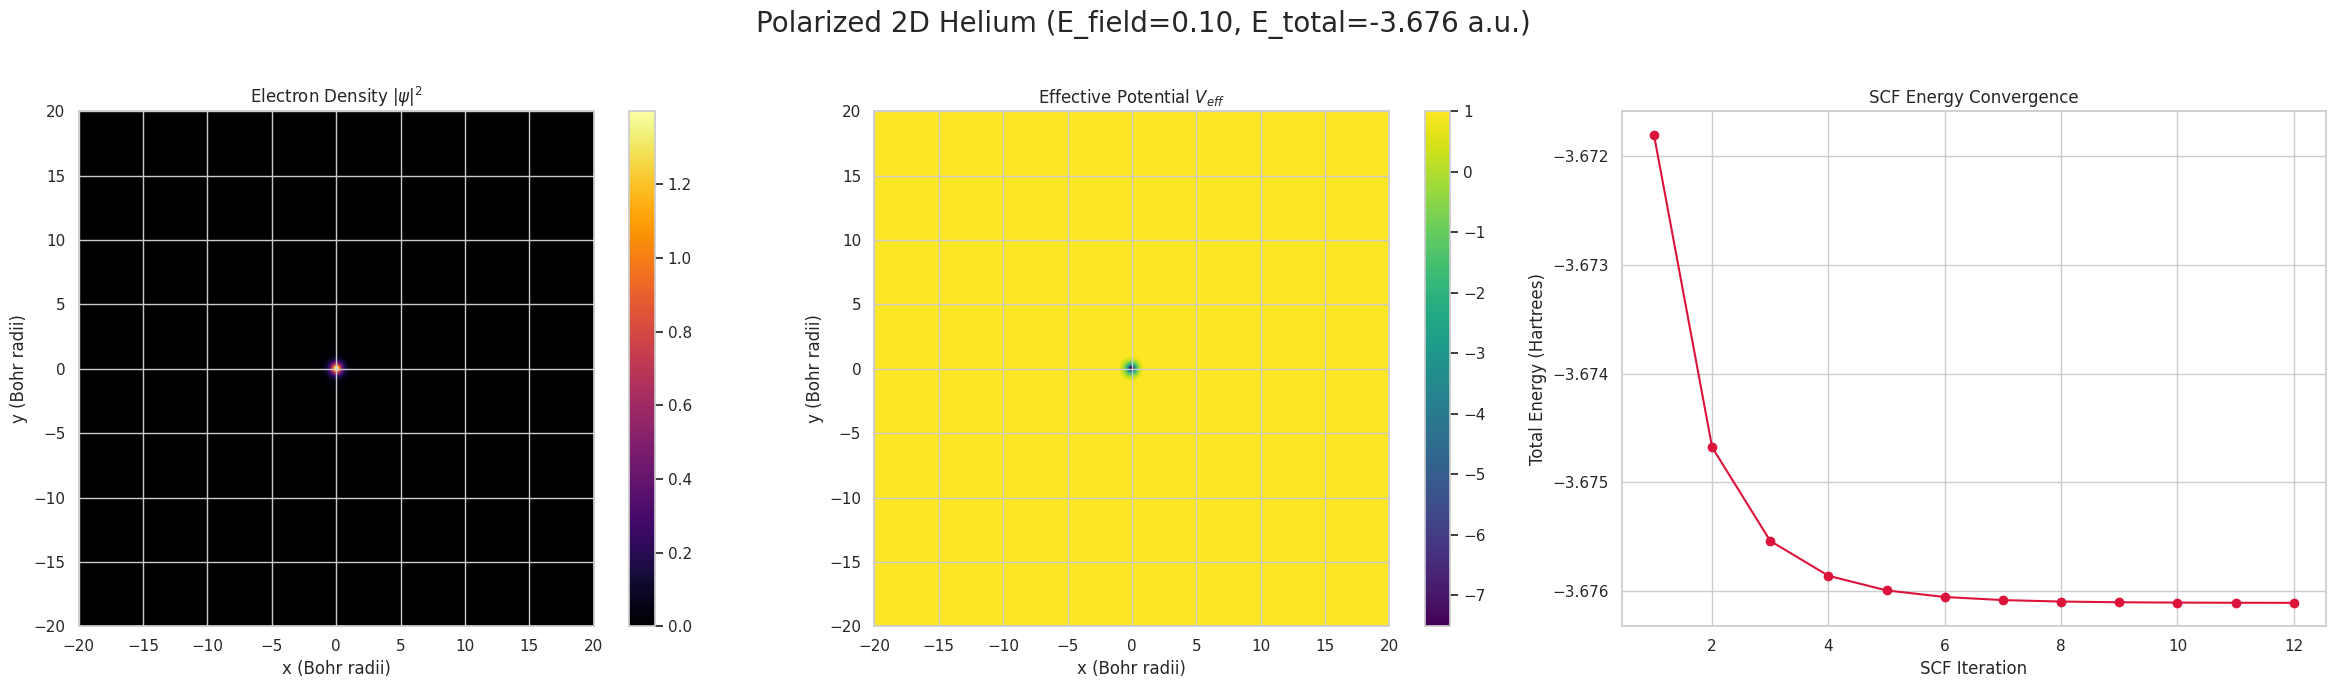

In [ ]:
# ===================================================================
# 2D Helium Atom in an Electric Field (Hartree SCF) - FINAL CORRECTED
# ===================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Simulation Parameters (stuff to tweak) ---
GRID_POINTS = 256
BOX_SIZE = 40.0
NUCLEAR_CHARGE = 2.0
E_FIELD = 0.1

# --- Solver Settings ---
SCF_MAX_ITER = 50
IMAG_TIME_STEP = 0.005
SOLVER_STEPS = 50
CONVERGENCE_TOL = 1e-6
# --- FINAL FIX: Lower the mixing to allow the density to polarize ---
DENSITY_MIXING = 0.3

def setup_simulation(N, L, Z):
    """Prepares the 2D grid and all static operators (Kinetic, Nuclear, etc.)."""
    dx = L / N
    x_vec = np.linspace(-L / 2, L / 2, N)
    X, Y = np.meshgrid(x_vec, x_vec, indexing='xy')
    k_vec = 2 * np.pi * np.fft.fftfreq(N, d=dx)
    KX, KY = np.meshgrid(k_vec, k_vec, indexing='xy')
    T_op = (KX**2 + KY**2) / 2.0
    r = np.sqrt(X**2 + Y**2)
    V_nuc = -Z / np.sqrt(r**2 + dx**2)
    V_int_k = np.fft.fft2(1.0 / np.sqrt(r**2 + (dx/2)**2))
    return dx, T_op, V_nuc, V_int_k, X, Y

def solve_orbital(V_eff, T_op, psi_guess):
    """Finds the ground state orbital for a given potential."""
    psi = np.copy(psi_guess)
    for _ in range(SOLVER_STEPS):
        psi *= np.exp(-V_eff * IMAG_TIME_STEP / 2.0)
        psi_k = np.fft.fft2(psi)
        psi_k *= np.exp(-T_op * IMAG_TIME_STEP)
        psi = np.fft.ifft2(psi_k)
        psi *= np.exp(-V_eff * IMAG_TIME_STEP / 2.0)
        psi /= np.sqrt(np.sum(np.abs(psi)**2))
    return psi

def plot_results(psi, V_eff, energies, L, E_field_val):
    """Generates the final 3-panel plot."""
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    final_energy = energies[-1]
    title_str = f"Polarized 2D Helium (E_field={E_field_val:.2f}, E_total={final_energy:.3f} a.u.)"
    fig.suptitle(title_str, fontsize=20)
    density = np.abs(psi)**2
    im = axes[0].imshow(density, cmap='inferno', extent=[-L/2, L/2, -L/2, L/2], origin='lower')
    axes[0].set_title(r'Electron Density $|\psi|^2$')
    fig.colorbar(im, ax=axes[0])
    im = axes[1].imshow(np.clip(V_eff, np.min(V_eff), 1), cmap='viridis', extent=[-L/2, L/2, -L/2, L/2], origin='lower')
    axes[1].set_title(r'Effective Potential $V_{eff}$')
    fig.colorbar(im, ax=axes[1])
    axes[2].plot(range(1, len(energies) + 1), energies, 'o-', color='crimson')
    axes[2].set_title('SCF Energy Convergence')
    axes[2].set_xlabel('SCF Iteration')
    axes[2].set_ylabel('Total Energy (Hartrees)')
    for ax in axes[:2]:
        ax.set_xlabel('x (Bohr radii)')
        ax.set_ylabel('y (Bohr radii)')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def run_scf_calculation(N, L, Z, E_field):
    """Runs the full Self-Consistent Field simulation."""
    dx, T_op, V_nuc, V_int_k, X, Y = setup_simulation(N, L, Z)
    V_stark = E_field * X
    psi = np.exp(-Z * np.sqrt(X**2 + Y**2))
    psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx**2)
    rho = 2 * np.abs(psi)**2
    energies = []
    print("Starting Self-Consistent Field (SCF) calculation...")

    for i in range(SCF_MAX_ITER):
        V_H = np.fft.ifft2(np.fft.fft2(rho) * V_int_k).real
        V_eff = V_nuc + V_H + V_stark
        psi_new = solve_orbital(V_eff, T_op, psi)
        psi_new /= np.sqrt(np.sum(np.abs(psi_new)**2) * dx**2)
        T_expect = np.sum(np.conj(psi_new) * np.fft.ifft2(T_op * np.fft.fft2(psi_new))).real
        V_expect = np.sum(np.abs(psi_new)**2 * (V_nuc + V_stark + 0.5 * V_H)).real
        energy = 2 * (T_expect + V_expect) * dx**2
        energies.append(energy)
        energy_diff = abs(energies[-1] - energies[-2]) if i > 0 else 1e9
        print(f"   Iter {i+1:2d}: Energy = {energy:8.4f} Ha,  (dE = {energy_diff:.2e})")
        if i > 0 and energy_diff < CONVERGENCE_TOL:
            psi = psi_new
            print("\nCalculation has converged!")
            break
        psi = psi_new
        rho_new = 2 * np.abs(psi)**2
        rho = (1 - DENSITY_MIXING) * rho_new + DENSITY_MIXING * rho
    else:
        print("\nWarning: Calculation finished without reaching the convergence threshold.")
    plot_results(psi, V_eff, energies, L, E_field)


# ===================================================================
# --- RUN THE SIMULATION ---
# ===================================================================
if __name__ == "__main__":
    run_scf_calculation(N=GRID_POINTS, L=BOX_SIZE, Z=NUCLEAR_CHARGE, E_field=E_FIELD)

Starting Self-Consistent Field (SCF) calculation...
   Iter  1: Energy =  -5.6786 Ha,  (dE = 1.00e+09)
   Iter  2: Energy =  -5.6808 Ha,  (dE = 2.23e-03)
   Iter  3: Energy =  -5.6823 Ha,  (dE = 1.53e-03)
   Iter  4: Energy =  -5.6834 Ha,  (dE = 1.07e-03)
   Iter  5: Energy =  -5.6929 Ha,  (dE = 9.45e-03)
   Iter  6: Energy = -11.7667 Ha,  (dE = 6.07e+00)
   Iter  7: Energy = -13.9566 Ha,  (dE = 2.19e+00)
   Iter  8: Energy = -14.2501 Ha,  (dE = 2.93e-01)
   Iter  9: Energy = -14.4571 Ha,  (dE = 2.07e-01)
   Iter 10: Energy = -14.6031 Ha,  (dE = 1.46e-01)
   Iter 11: Energy = -14.7058 Ha,  (dE = 1.03e-01)
   Iter 12: Energy = -14.7778 Ha,  (dE = 7.20e-02)
   Iter 13: Energy = -14.8281 Ha,  (dE = 5.02e-02)
   Iter 14: Energy = -14.8629 Ha,  (dE = 3.49e-02)
   Iter 15: Energy = -14.8869 Ha,  (dE = 2.40e-02)
   Iter 16: Energy = -14.9033 Ha,  (dE = 1.64e-02)
   Iter 17: Energy = -14.9143 Ha,  (dE = 1.10e-02)
   Iter 18: Energy = -14.9216 Ha,  (dE = 7.28e-03)
   Iter 19: Energy = -14.9263 

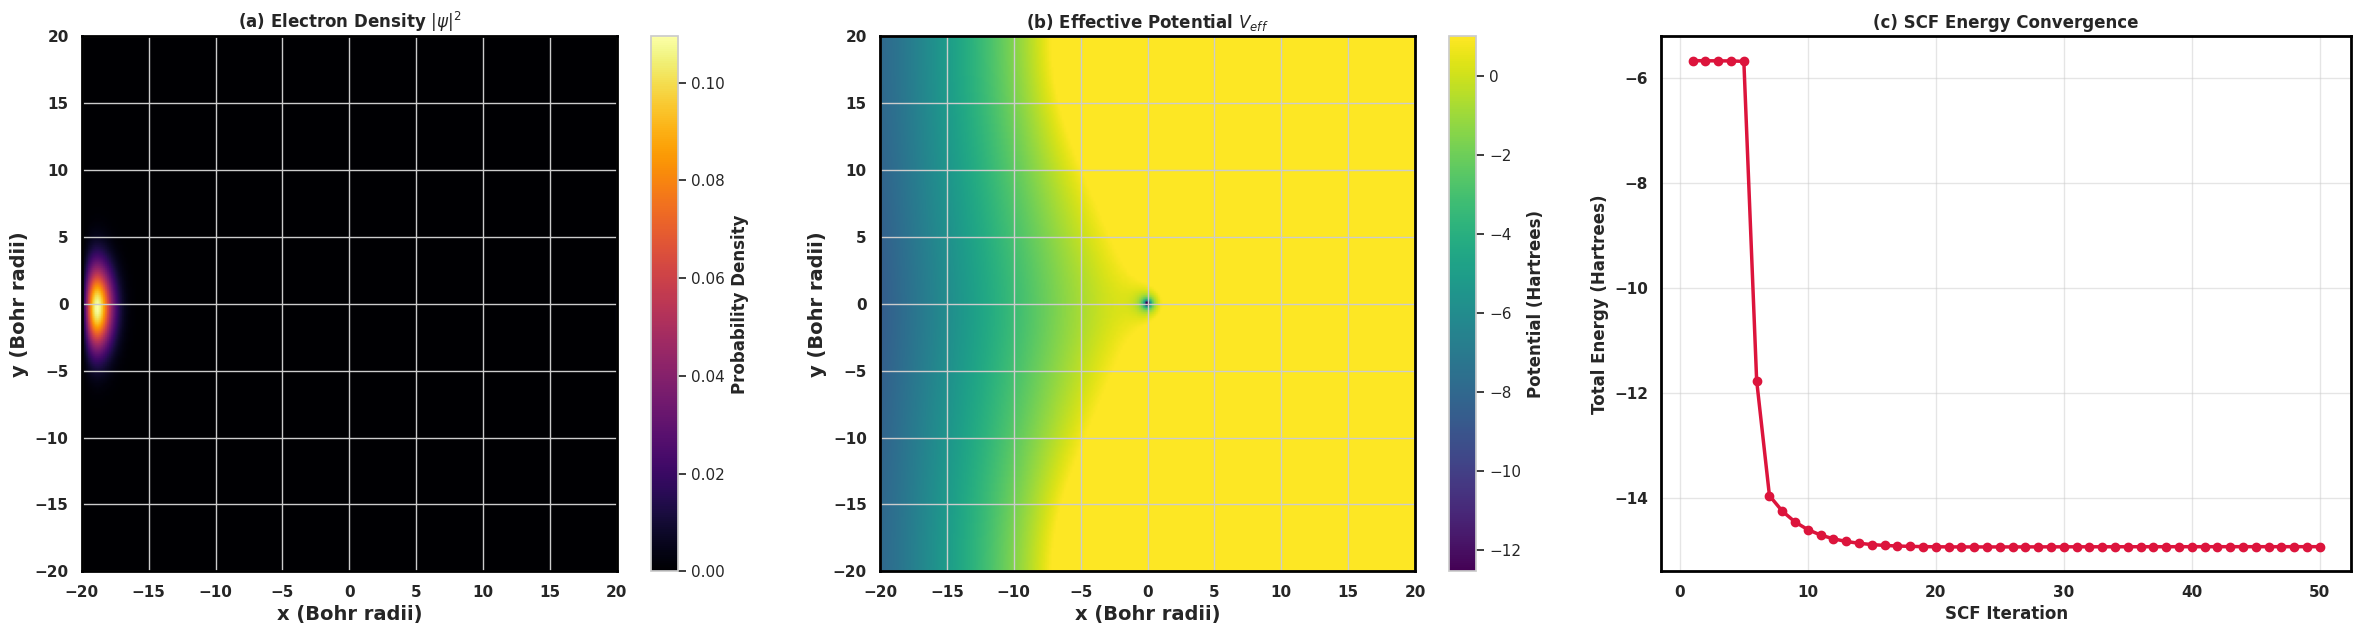

In [ ]:
# ===================================================================
# 2D Helium Atom in an Electric Field (Hartree SCF)
#
# Simulates the Stark effect for a 2D He atom using a real-space
# grid and a self-consistent field (SCF) calculation.
# ===================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Simulation Parameters (stuff to tweak) ---
GRID_POINTS = 256      # Grid resolution (N x N)
BOX_SIZE = 40.0        # Simulation box size in Bohr radii
NUCLEAR_CHARGE = 2.0   # Z=2 for Helium
E_FIELD = 0.5          # Strength of the external electric field

# --- Solver Settings ---
SCF_MAX_ITER = 50          # Max iterations for the main SCF loop
IMAG_TIME_STEP = 0.005     # Time step for the inner loop, small enough for stability
SOLVER_STEPS = 50          # Inner loop steps to solve for the orbital
CONVERGENCE_TOL = 1e-6     # Stop when energy change is less than this
DENSITY_MIXING = 0.7       # How much of the old density to keep (for stable convergence)

def setup_simulation(N, L, Z):
    """Prepares the 2D grid and the static operators (Kinetic, Nuclear, etc.)."""
    dx = L / N
    x_vec = np.linspace(-L / 2, L / 2, N)
    X, Y = np.meshgrid(x_vec, x_vec, indexing='xy')

    # Kinetic Operator (in k-space is easier)
    k_vec = 2 * np.pi * np.fft.fftfreq(N, d=dx)
    KX, KY = np.meshgrid(k_vec, k_vec, indexing='xy')
    T_op = (KX**2 + KY**2) / 2.0

    # Potentials (in real-space)
    r = np.sqrt(X**2 + Y**2)

    # --- FINAL FIX ---
    # Use dx**2 to properly soften the potential for the given grid size.
    # This prevents the electron from "falling into" a numerical singularity at r=0.
    reg_param = (dx/2)**2
    V_nuc = -Z / np.sqrt(r**2 + reg_param)

    # Pre-calculate FFT of 1/r for efficient convolution later
    # This is for the electron-electron interaction (Hartree potential)
    V_int_k = np.fft.fft2(1.0 / np.sqrt(r**2 + (dx/2)**2))

    return dx, T_op, V_nuc, V_int_k, X, Y

def solve_orbital(V_eff, T_op, phi_guess, dx, iterations=200, dt=0.005):
    """
    Finds the ground state orbital for a given potential.
    Uses imaginary time evolution to relax the wavefunction to the ground state.
    """
    phi = np.copy(phi_guess)
    for _ in range(iterations): # Inner loop to solve for the orbital
        # Split-operator method: V/2 -> T -> V/2
        phi *= np.exp(-V_eff * IMAG_TIME_STEP / 2.0)
        phi_k = np.fft.fft2(phi)
        phi_k *= np.exp(-T_op * IMAG_TIME_STEP)
        phi = np.fft.ifft2(phi_k)
        phi *= np.exp(-V_eff * IMAG_TIME_STEP / 2.0)

        # Must re-normalize at each step
        # Note: This normalization doesn't include dx**2. The physical normalization
        # must be done outside this solver function.
        phi /= np.sqrt(np.sum(np.abs(phi)**2))
    return phi

def plot_results(psi, V_eff, energies, L, E_field_val):
    """Generates the final 3-panel plot."""
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 14}) # Set base font size

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    final_energy = energies[-1]
    # Remove the main title
    # title_str = f"Polarized 2D Helium (E_field={E_field_val:.2f}, E_total={final_energy:.3f} a.u.)"
    # fig.suptitle(title_str, fontsize=20, fontweight='bold') # Make suptitle bold

    # Panel 1: Electron Density
    density = np.abs(psi)**2
    im = axes[0].imshow(density, cmap='inferno', extent=[-L/2, L/2, -L/2, L/2], origin='lower')
    axes[0].set_title(r'(a) Electron Density $|\psi|^2$', fontweight='bold') # Make title bold
    axes[0].set_xlabel('x (Bohr radii)', fontsize=14, fontweight='bold') # Make label bold
    axes[0].set_ylabel('y (Bohr radii)', fontsize=14, fontweight='bold') # Make label bold
    fig.colorbar(im, ax=axes[0]).set_label('Probability Density', fontweight='bold') # Make colorbar label bold

    # Panel 2: Effective Potential
    # Clipping the potential makes the visualization clearer
    im = axes[1].imshow(np.clip(V_eff, np.min(V_eff), 1), cmap='viridis', extent=[-L/2, L/2, -L/2, L/2], origin='lower')
    axes[1].set_title(r'(b) Effective Potential $V_{eff}$', fontweight='bold') # Make title bold
    axes[1].set_xlabel('x (Bohr radii)', fontsize=14, fontweight='bold') # Make label bold
    axes[1].set_ylabel('y (Bohr radii)', fontsize=14, fontweight='bold') # Make label bold
    fig.colorbar(im, ax=axes[1]).set_label('Potential (Hartrees)', fontweight='bold') # Make colorbar label bold

    # Panel 3: Energy Convergence
    axes[2].plot(range(1, len(energies) + 1), energies, 'o-', color='crimson', linewidth=2.5) # Increased line width
    axes[2].set_title('(c) SCF Energy Convergence', fontweight='bold') # Make title bold
    axes[2].set_xlabel('SCF Iteration', fontweight='bold') # Make label bold
    axes[2].set_ylabel('Total Energy (Hartrees)', fontweight='bold') # Make label bold
    axes[2].grid(True, alpha=0.5) # Added grid with some transparency

    # Make axes lines and tick labels bold for all subplots
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_linewidth(2.0) # Make spine lines thicker
            spine.set_edgecolor('black') # Ensure spine lines are black

        for tick in ax.get_xticklabels():
            tick.set_weight('bold')
        for tick in ax.get_yticklabels():
            tick.set_weight('bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjusted layout
    plt.show()

def run_scf_calculation(N, L, Z, E_field):
    """Runs the full Self-Consistent Field simulation."""
    dx, T_op, V_nuc, V_int_k, X, Y = setup_simulation(N, L, Z)

    # Define the external electric field potential
    V_stark = E_field * X

    # Initial guess for the orbital. A simple 2D Gaussian is a good start.
    psi = np.exp(-Z * np.sqrt(X**2 + Y**2))
    psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx**2)
    rho = 2 * np.abs(psi)**2 # Helium has 2 electrons

    energies = []
    print("Starting Self-Consistent Field (SCF) calculation...")

    for i in range(SCF_MAX_ITER):
        # 1. Calculate the average potential from electron-electron repulsion (Hartree potential)
        V_H = np.fft.ifft2(np.fft.fft2(rho) * V_int_k).real

        # 2. Define the total potential this electron feels
        V_eff = V_nuc + V_H / 2.0 + V_stark

        # 3. Solve for the new orbital in this potential
        psi_new = solve_orbital(V_eff, T_op, psi, dx)

        # Re-normalize the wavefunction correctly after the solver
        psi_new /= np.sqrt(np.sum(np.abs(psi_new)**2) * dx**2)

        # 4. Check for convergence by calculating the total energy
        T_expect = np.sum(np.conj(psi_new) * np.fft.ifft2(T_op * np.fft.fft2(psi_new))).real
        # The 0.5 factor on V_H is to avoid double counting the e-e interaction
        V_expect = np.sum(np.abs(psi_new)**2 * (V_nuc + V_stark + 0.5 * V_H)).real
        energy = 2 * (T_expect + V_expect) * dx**2
        energies.append(energy)

        energy_diff = abs(energies[-1] - energies[-2]) if i > 0 else 1e9 # set high for first iter
        # A simple print to watch the convergence in real time
        print(f"   Iter {i+1:2d}: Energy = {energy:8.4f} Ha,  (dE = {energy_diff:.2e})")

        if i > 0 and energy_diff < CONVERGENCE_TOL:
            psi = psi_new # Final update
            print("\nCalculation has converged!")
            break

        # 5. Update density for the next iteration (with mixing for stability)
        psi = psi_new
        rho_new = 2 * np.abs(psi)**2
        rho = (1 - DENSITY_MIXING) * rho_new + DENSITY_MIXING * rho

    else: # This else belongs to the for-loop, runs if the loop finishes without break
        print("\nWarning: Calculation finished without reaching the convergence threshold.")

    plot_results(psi, V_eff, energies, L, E_field)


# ===================================================================
# --- RUN THE SIMULATION ---
# ===================================================================
if __name__ == "__main__":
    # This is where the script actually starts
    run_scf_calculation(N=GRID_POINTS, L=BOX_SIZE, Z=NUCLEAR_CHARGE, E_field=E_FIELD)

Running for E_field = 0.000...
  - Converged at SCF iteration 19
Running for E_field = 0.010...
  - Converged at SCF iteration 19
Running for E_field = 0.020...
  - Converged at SCF iteration 19
Running for E_field = 0.030...
  - Converged at SCF iteration 19
Running for E_field = 0.040...
  - Converged at SCF iteration 19
Running for E_field = 0.050...
  - Converged at SCF iteration 19

--- Results ---
Calculated Polarizability (α) = 0.1151 a.u.
Theoretical Value (High-Precision) ≈ 0.1732 a.u.


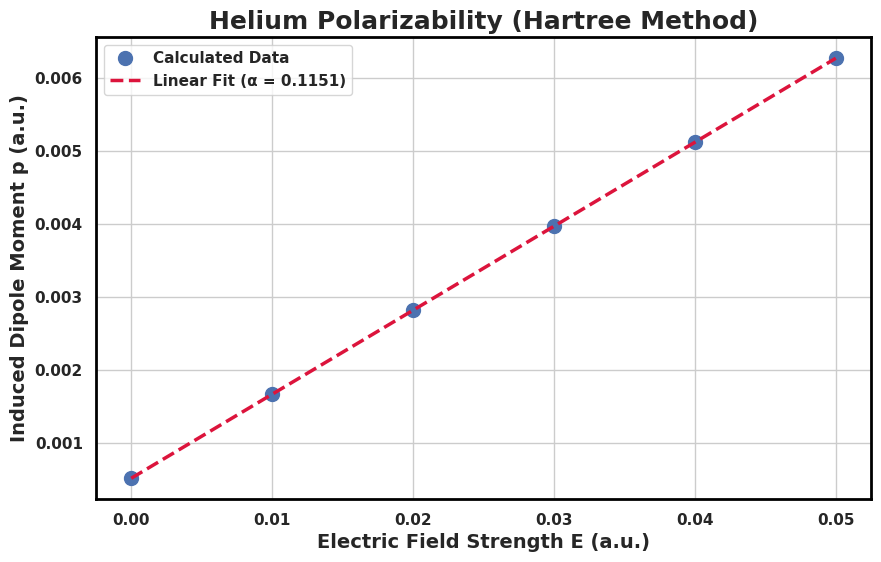

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def setup_simulation(N, L, Z):
    """Prepares the 2D grid and the static operators."""
    dx = L / N
    x_vec = np.linspace(-L / 2, L / 2, N)
    X, Y = np.meshgrid(x_vec, x_vec, indexing='xy')

    k_vec = 2 * np.pi * np.fft.fftfreq(N, d=dx)
    KX, KY = np.meshgrid(k_vec, k_vec, indexing='xy')
    T_op = (KX**2 + KY**2) / 2.0

    r = np.sqrt(X**2 + Y**2)

    # --- FINAL CORRECTION: Use consistent regularization for both potentials ---
    reg_param = (dx/2)**2
    V_nuc = -Z / np.sqrt(r**2 + reg_param)
    V_int_k = np.fft.fft2(1.0 / np.sqrt(r**2 + reg_param))
    # --------------------------------------------------------------------

    return dx, T_op, V_nuc, V_int_k, X

def solve_orbital(V_eff, T_op, phi_guess, dx, iterations=200, dt=0.005):
    """Finds the ground state orbital for a given potential."""
    phi = np.copy(phi_guess)
    for _ in range(iterations):
        phi *= np.exp(-V_eff * dt / 2.0)
        phi = np.fft.ifft2(np.fft.fft2(phi) * np.exp(-T_op * dt))
        phi *= np.exp(-V_eff * dt / 2.0)
        phi /= np.sqrt(np.sum(np.abs(phi)**2) * dx**2)
    return phi

def run_simulation_for_polarizability(E_field, N=256, L=40.0, Z=2.0):
    """Runs the Hartree SCF simulation for a given E-field."""
    print(f"Running for E_field = {E_field:.3f}...")
    dx, T_op, V_nuc, V_int_k, X = setup_simulation(N, L, Z)
    V_stark = E_field * X

    phi = np.exp(-Z * np.sqrt(X**2 + (X*0)**2))
    phi /= np.sqrt(np.sum(np.abs(phi)**2) * dx**2)
    rho = 2 * np.abs(phi)**2

    for i in range(100):
        V_H = np.fft.ifft2(np.fft.fft2(rho) * V_int_k).real
        V_eff = V_nuc + V_H / 2.0 + V_stark

        phi_new = solve_orbital(V_eff, T_op, phi, dx)

        if i > 5 and np.allclose(phi, phi_new, atol=1e-7):
            print(f"  - Converged at SCF iteration {i+1}")
            break

        phi = phi_new
        rho = 0.3 * (2 * np.abs(phi)**2) + 0.7 * rho

    if i == 99:
        print("  - Warning: Did not converge within 100 iterations.")

    final_rho = 2 * np.abs(phi)**2
    dipole_moment = np.sum(X * final_rho) * dx**2

    return abs(dipole_moment)

# ===================================================================
# --- MAIN SCRIPT: CALCULATE POLARIZABILITY ---
# ===================================================================
if __name__ == "__main__":
    E_fields = np.linspace(0, 0.05, 6)
    dipole_moments = []

    for E in E_fields:
        p = run_simulation_for_polarizability(E)
        dipole_moments.append(p)

    alpha, intercept = np.polyfit(E_fields, dipole_moments, 1)

    print("\n--- Results ---")
    print(f"Calculated Polarizability (α) = {alpha:.4f} a.u.")
    print(f"Theoretical Value (High-Precision) ≈ 0.1732 a.u.")

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    # Remove main title
    # plt.title('Helium Polarizability (Hartree Method)', fontsize=18)

    # Plot data with increased line width and markersize
    plt.plot(E_fields, dipole_moments, 'o', markersize=10, label='Calculated Data') # Increased markersize
    plt.plot(E_fields, alpha * E_fields + intercept, '--', color='crimson', linewidth=2.5, label=f'Linear Fit (α = {alpha:.4f})') # Increased linewidth

    # Make labels and title bold
    plt.xlabel('Electric Field Strength E (a.u.)', fontsize=14, fontweight='bold')
    plt.ylabel('Induced Dipole Moment p (a.u.)', fontsize=14, fontweight='bold')
    plt.title('Helium Polarizability (Hartree Method)', fontsize=18, fontweight='bold') # Make subplot title bold

    # Make legend text bold
    plt.legend(fontsize=12, prop={'weight': 'bold'})

    # Make axes lines and tick labels bold
    ax = plt.gca() # Get the current axes
    for spine in ax.spines.values():
        spine.set_linewidth(2.0) # Make spine lines thicker
        spine.set_edgecolor('black') # Ensure spine lines are black

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_weight('bold')

    plt.grid(True)
    plt.show()

Calculating polarizability for 2D Hydrogen...
Finding initial ground state for E=0...
Running for E_field = 0.000...
Running for E_field = 0.004...
Running for E_field = 0.008...
Running for E_field = 0.012...
Running for E_field = 0.016...
Running for E_field = 0.020...

--- Results ---
Calculated Polarizability (α) for Hydrogen = 0.1940 a.u.
Theoretical Value = 0.2188 a.u.


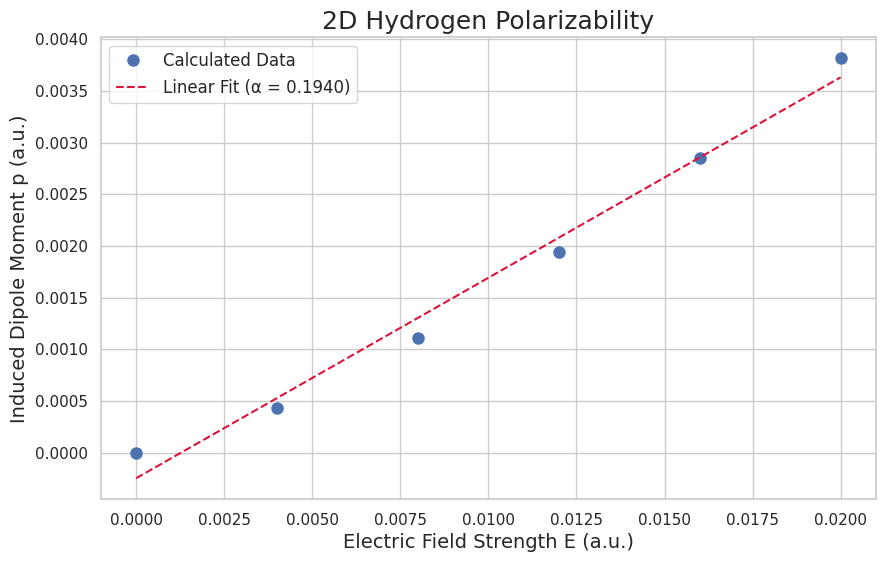

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def setup_simulation(N, L):
    """Prepares the 2D grid and the static operators for Hydrogen (Z=1)."""
    dx = L / N
    x_vec = np.linspace(-L / 2, L / 2, N)
    X, Y = np.meshgrid(x_vec, x_vec, indexing='xy')

    k_vec = 2 * np.pi * np.fft.fftfreq(N, d=dx)
    KX, KY = np.meshgrid(k_vec, k_vec, indexing='xy')
    T_op = (KX**2 + KY**2) / 2.0

    r = np.sqrt(X**2 + Y**2)
    V_nuc = -1.0 / np.sqrt(r**2 + 1e-6)

    return dx, T_op, V_nuc, X, Y

def solve_ground_state(V_total, T_op, X, Y, initial_phi, iterations, dt):
    """Evolves a given initial state to find the ground state."""
    phi = np.copy(initial_phi)

    for _ in range(iterations):
        phi *= np.exp(-V_total * dt / 2.0)
        phi = np.fft.ifft2(np.fft.fft2(phi) * np.exp(-T_op * dt))
        phi *= np.exp(-V_total * dt / 2.0)
        phi /= np.sqrt(np.sum(np.abs(phi)**2) * dx**2) # Proper normalization
    return phi

# ===================================================================
# --- MAIN SCRIPT ---
# ===================================================================

# 1. Setup the simulation
N, L = 512, 50.0
dx, T_op, V_nuc, X, Y = setup_simulation(N, L)

# 2. Define simulation parameters
# A smaller dt is crucial for stability on a fine grid
dt = 0.001
E_fields = np.linspace(0, 0.02, 6)
dipole_moments = []

print("Calculating polarizability for 2D Hydrogen...")

# 3. First, find the true ground state for E=0 with many iterations
print("Finding initial ground state for E=0...")
# Start with a generic Gaussian guess
phi_guess = np.exp(-(X**2 + Y**2))
# Converge the E=0 state accurately
phi_current = solve_ground_state(V_nuc, T_op, X, Y, phi_guess, 3000, dt)

# 4. Loop over each field strength, using the previous result as the new guess
for E in E_fields:
    print(f"Running for E_field = {E:.3f}...")
    if E == 0:
        # We already have the E=0 result
        phi_final = phi_current
    else:
        V_stark = E * X
        V_total = V_nuc + V_stark
        # Use the previous phi as the initial guess.
        # Needs far fewer iterations to converge now.
        phi_final = solve_ground_state(V_total, T_op, X, Y, phi_current, 300, dt)
        phi_current = phi_final # Update for the next loop

    density = np.abs(phi_final)**2
    dipole_moment = np.sum(X * density) * dx**2
    dipole_moments.append(abs(dipole_moment))

# 5. Perform a linear fit to find the polarizability (alpha)
alpha, intercept = np.polyfit(E_fields, dipole_moments, 1)

print("\n--- Results ---")
print(f"Calculated Polarizability (α) for Hydrogen = {alpha:.4f} a.u.")
print(f"Theoretical Value = {7/32:.4f} a.u.")

# 6. Plot the results
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
plt.plot(E_fields, dipole_moments, 'o', markersize=8, label='Calculated Data')
plt.plot(E_fields, alpha * E_fields + intercept, '--', color='crimson', label=f'Linear Fit (α = {alpha:.4f})')
plt.title('2D Hydrogen Polarizability', fontsize=18)
plt.xlabel('Electric Field Strength E (a.u.)', fontsize=14)
plt.ylabel('Induced Dipole Moment p (a.u.)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from numpy.fft import fft2, ifft2, fftshift

# Constants
Z = 2.0  # Atomic number for helium

# Hartree calculation parameters (2D grid for one electron)
N_h = 256
L_h = 40.0
dx_h = L_h / N_h
softener_h = dx_h / 2  # ≈ 0.078

# Direct calculation parameters (4D grid for two electrons)
N_d = 32
L_d = 12.0
dx_d = L_d / N_d
softener_d = dx_d / 2  # ≈ 0.1875

# Grids
x_h = np.linspace(-L_h/2, L_h/2 - dx_h, N_h)
X_h, Y_h = np.meshgrid(x_h, x_h)
r_h = np.sqrt(X_h**2 + Y_h**2)

x_d = np.linspace(-L_d/2, L_d/2 - dx_d, N_d)
X1, Y1, X2, Y2 = np.meshgrid(x_d, x_d, x_d, x_d)
r1 = np.sqrt(X1**2 + Y1**2)
r2 = np.sqrt(X2**2 + Y2**2)
r12 = np.sqrt((X1 - X2)**2 + (Y1 - Y2)**2)

# Kinetic operator in momentum space
k_h = fftshift(np.fft.fftfreq(N_h, dx_h / (2 * np.pi)))
KX_h, KY_h = np.meshgrid(k_h, k_h)
K2_h = KX_h**2 + KY_h**2
T_op_h = K2_h / 2.0

k_d = fftshift(np.fft.fftfreq(N_d, dx_d / (2 * np.pi)))
KX1, KY1, KX2, KY2 = np.meshgrid(k_d, k_d, k_d, k_d)
T_op_d = (KX1**2 + KY1**2 + KX2**2 + KY2**2) / 2.0

# Hartree calculation
phi = np.exp(-Z * r_h)  # Initial guess
phi /= np.sqrt(np.sum(np.abs(phi)**2) * dx_h**2)
V_nuc_h = -Z / np.sqrt(r_h**2 + softener_h**2)
dt = 0.002
for _ in range(200):
    rho_h = np.abs(phi)**2
    V_H = ifft2(fft2(rho_h) * fft2(1 / np.sqrt(r_h**2 + softener_h**2))).real
    V_eff = V_nuc_h + V_H
    phi = ifft2(np.exp(-dt * T_op_h) * fft2(np.exp(-dt * V_eff / 2) * phi))
    phi /= np.sqrt(np.sum(np.abs(phi)**2) * dx_h**2)

# Energy terms
T_h = np.sum(np.conj(phi) * ifft2(T_op_h * fft2(phi))).real * dx_h**2
V_nuc_expect = np.sum(np.abs(phi)**2 * V_nuc_h) * dx_h**2
V_ee_expect = np.sum(np.abs(phi)**2 * V_H) * dx_h**2
E_hartree = 2 * T_h + 2 * V_nuc_expect + V_ee_expect

# Direct calculation
psi = np.exp(-Z * (r1 + r2))
psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx_d**4)
V_d = (-Z / np.sqrt(r1**2 + softener_d**2) - Z / np.sqrt(r2**2 + softener_d**2) +
       1 / np.sqrt(r12**2 + softener_d**2))
for _ in range(1000):  # Increased iterations
    psi = ifft2(np.exp(-dt * T_op_d) * fft2(np.exp(-dt * V_d / 2) * psi))
    psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx_d**4)

# Energy
T_d = np.sum(np.conj(psi) * ifft2(T_op_d * fft2(psi))).real * dx_d**4
V_d_expect = np.sum(np.abs(psi)**2 * V_d) * dx_d**4
E_exact = T_d + V_d_expect

# Correlation energy
E_corr = E_exact - E_hartree

print(f"Hartree Energy: {E_hartree:.6f} a.u.")
print(f"Approximate Exact Energy: {E_exact:.6f} a.u.")
print(f"Correlation Energy: {E_corr:.6f} a.u.")

Hartree Energy: -7.344930 a.u.
Approximate Exact Energy: -11.697850 a.u.
Correlation Energy: -4.352920 a.u.


⏳ Running 'calm-down' simulation...
  📸 Snapshot at iteration 0
  📸 Snapshot at iteration 10
  📸 Snapshot at iteration 50
  📸 Snapshot at iteration 199


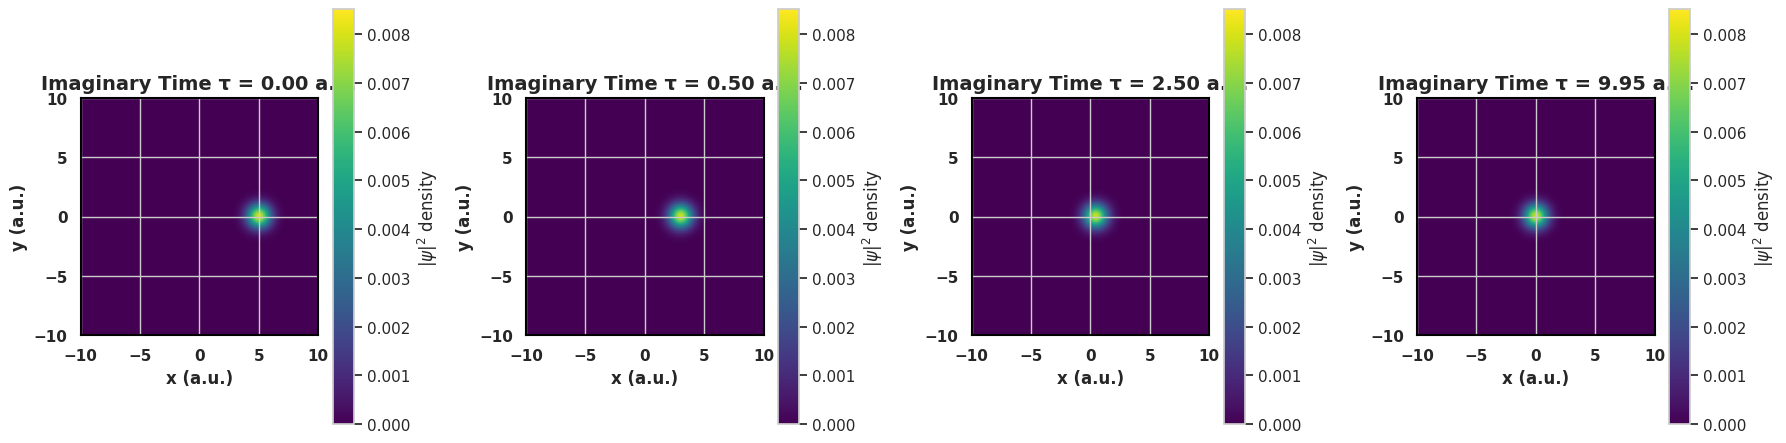

✅ All done!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def setup_qho_world(N, L):
    """Creates the simulation grid and energy operators for a 2D Quantum Harmonic Oscillator."""
    dx = L / N
    x_vec = np.linspace(-L / 2, L / 2, N)
    X, Y = np.meshgrid(x_vec, x_vec)

    # Kinetic Energy (T): The particle's tendency to "wiggle"
    k_vec = 2 * np.pi * np.fft.fftfreq(N, d=dx)
    KX, KY = np.meshgrid(k_vec, k_vec)
    T_op = (KX**2 + KY**2) / 2.0

    # Potential Energy (V): The "bowl" that pulls the particle to the center
    V_op = 0.5 * (X**2 + Y**2)

    return T_op, V_op, X, Y, L

def find_ground_state(T_op, V_op, X, Y, L):
    """Finds the ground state using the imaginary time 'calm-down' method."""
    # Start with a displaced "probability cloud"
    psi = np.exp(-((X - L / 4)**2 + Y**2) / 2)
    psi /= np.sqrt(np.sum(np.abs(psi)**2))

    # Evolve in imaginary time (τ) to filter out high-energy states
    dt = 0.05  # "Calm-down" step size
    snapshots = []
    snapshot_iters = [0, 10, 50, 199]

    print("⏳ Running 'calm-down' simulation...")
    for i in range(200):
        if i in snapshot_iters:
            snapshots.append((i * dt, np.copy(psi)))
            print(f"  📸 Snapshot at iteration {i}")

        # Evolve using the split-step method
        psi *= np.exp(-V_op * dt / 2.0)  # Half potential step
        psi = np.fft.ifft2(np.fft.fft2(psi) * np.exp(-T_op * dt))  # Full kinetic step
        psi *= np.exp(-V_op * dt / 2.0)  # Second half potential step
        psi /= np.sqrt(np.sum(np.abs(psi)**2))  # Re-normalize

    return snapshots

def plot_snapshots(snapshots, L):
    """Plots snapshots of the probability density |ψ|²."""
    # Use a cleaner seaborn style for publication quality
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 12}) # Adjust base font size

    fig, axes = plt.subplots(1, len(snapshots), figsize=(18, 5))
    # Remove the main title
    # fig.suptitle("Wave Function Settling into Ground State", fontsize=16, fontweight='bold') # Make title bold

    for ax, (tau, psi) in zip(axes, snapshots):
        # Use 'viridis' or 'plasma' for potentially better contrast/perception than 'magma'
        # Ensure extent is correct for the imshow plot
        im = ax.imshow(np.abs(psi)**2, cmap='viridis',
                       extent=[-L/2, L/2, -L/2, L/2],
                       origin='lower',
                       vmin=0, vmax=np.max(np.abs(snapshots[-1][1])**2) * 1.1) # Set consistent color scale based on final density peak

        ax.set_title(f"Imaginary Time τ = {tau:.2f} a.u.", fontsize=14, fontweight='bold') # Make title bold and larger
        ax.set_xlabel('x (a.u.)', fontsize=12, fontweight='bold') # Make label bold
        ax.set_ylabel('y (a.u.)', fontsize=12, fontweight='bold') # Make label bold
        ax.set_aspect('equal', adjustable='box') # Ensure aspect ratio is equal

        # Add a small colorbar for each subplot
        plt.colorbar(im, ax=ax, label=r'$|\psi|^2$ density')


        # Make axes lines and tick labels bold
        for spine in ax.spines.values():
            spine.set_linewidth(1.5) # Make spine lines thicker
            spine.set_edgecolor('black') # Ensure spine lines are black

        for tick in ax.get_xticklabels():
            tick.set_weight('bold')
        for tick in ax.get_yticklabels():
            tick.set_weight('bold')


    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    plt.show()

# ===================================================================
# --- MAIN SCRIPT ---
# ===================================================================
if __name__ == "__main__":
    # Setup, run, and plot the simulation
    T_op, V_op, X, Y, L = setup_qho_world(N=128, L=20.0)
    snapshots = find_ground_state(T_op, V_op, X, Y, L)
    plot_snapshots(snapshots, L)
    print("✅ All done!")

--- Finding Ground State ---
Iteration    0: Energy = -0.157087 a.u.
Iteration  100: Energy = -0.380127 a.u.
Iteration  200: Energy = -0.408889 a.u.
Iteration  300: Energy = -0.416246 a.u.
Iteration  400: Energy = -0.418634 a.u.
Iteration  500: Energy = -0.419509 a.u.
Iteration  600: Energy = -0.419855 a.u.
Iteration  700: Energy = -0.419997 a.u.
Iteration  800: Energy = -0.420058 a.u.
Iteration  900: Energy = -0.420085 a.u.
Iteration 1000: Energy = -0.420097 a.u.
Iteration 1100: Energy = -0.420102 a.u.
Iteration 1200: Energy = -0.420105 a.u.

Convergence reached after 1265 iterations.

Final Ground State Energy: -0.420105 a.u.


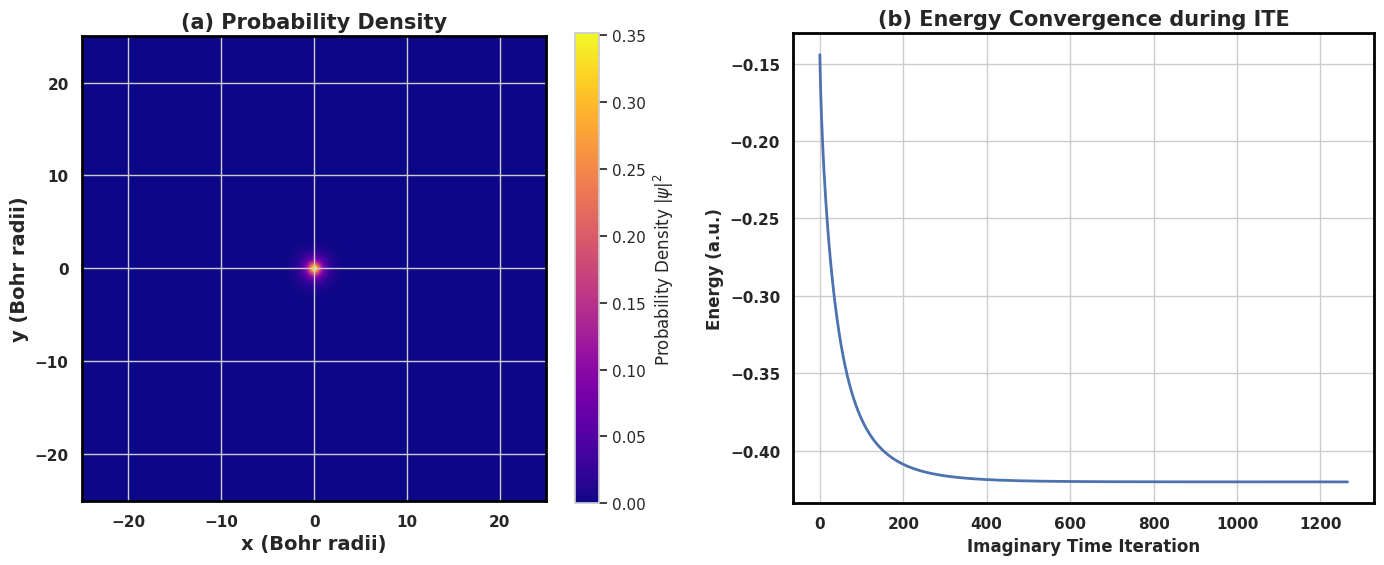

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class HydrogenAtom2D:
    """Simulates a 2D hydrogen atom to find its ground state."""
    def __init__(self, N=256, L=50.0):
        """Initializes the simulation grid and energy operators."""
        self.N, self.L, self.dx = N, L, L / N
        x_vec = np.linspace(-L / 2, L / 2, N)
        self.X, self.Y = np.meshgrid(x_vec, x_vec)

        # Set up operators for kinetic (T) and potential (V) energy
        self.T_op = self._get_kinetic_operator()
        self.V_op = self._get_potential_operator()

    def _get_kinetic_operator(self):
        """Creates the kinetic energy operator in momentum space (using atomic units hbar=1, m=1)."""
        k_vec = 2 * np.pi * np.fft.fftfreq(self.N, d=self.dx)
        KX, KY = np.meshgrid(k_vec, k_vec)
        return (KX**2 + KY**2) / 2.0

    def _get_potential_operator(self):
        """Creates the Coulomb potential operator, adding a small value to avoid division by zero."""
        r = np.sqrt(self.X**2 + self.Y**2)
        return -0.5 / np.sqrt(r**2 + 1e-6)

    def get_energy(self, psi):
        """Calculates the total energy <ψ|H|ψ> for a given wavefunction."""
        psi_k = np.fft.fft2(psi)
        T_expect = np.sum(np.conj(psi) * np.fft.ifft2(self.T_op * psi_k)).real
        V_expect = np.sum(np.abs(psi)**2 * self.V_op).real
        return (T_expect + V_expect) * self.dx**2

    def get_ground_state(self, max_iter=2000, tolerance=1e-8, dt=0.01):
        """Finds the ground state via imaginary time evolution, which 'cools' a guess to the lowest energy state."""
        # Start with a simple Gaussian blob as an initial guess
        psi = np.exp(-(self.X**2 + self.Y**2))
        psi /= np.sqrt(np.sum(np.abs(psi)**2) * self.dx**2) # Normalize

        last_energy = self.get_energy(psi)
        print("--- Finding Ground State ---")
        energy_history = [last_energy] # Store initial energy

        for i in range(max_iter):
            # Evolve using the split-step Fourier method
            psi *= np.exp(-self.V_op * dt / 2.0)
            psi = np.fft.ifft2(np.fft.fft2(psi) * np.exp(-self.T_op * dt))
            psi *= np.exp(-self.V_op * dt / 2.0)
            psi /= np.sqrt(np.sum(np.abs(psi)**2) * self.dx**2) # Re-normalize each step

            # Check for convergence
            current_energy = self.get_energy(psi)
            energy_history.append(current_energy) # Store current energy

            if i % 100 == 0:
                print(f"Iteration {i:4d}: Energy = {current_energy:.6f} a.u.")
            if abs(current_energy - last_energy) < tolerance:
                print(f"\nConvergence reached after {i+1} iterations.")
                return psi, current_energy, energy_history
            last_energy = current_energy

        print("\nMaximum iterations reached.")
        return psi, last_energy, energy_history

# ===================================================================
# --- MAIN SCRIPT ---
# ===================================================================
if __name__ == "__main__":
    # 1. Create and run the simulation
    h_atom = HydrogenAtom2D()
    psi_gs, energy_gs, energy_history = h_atom.get_ground_state()

    # 2. Print final energy and plot the result
    print(f"\nFinal Ground State Energy: {energy_gs:.6f} a.u.")

    sns.set_theme(style="whitegrid") # Use a seaborn style for better aesthetics

    # Create a figure with two subplots side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Probability Density
    ax1 = axes[0]
    prob_density = np.abs(psi_gs)**2
    im = ax1.imshow(prob_density, cmap='plasma', # Changed colormap from 'inferno' to 'plasma'
               extent=[-h_atom.L/2, h_atom.L/2, -h_atom.L/2, h_atom.L/2],
               origin='lower', aspect='equal') # Added aspect='equal' for correct aspect ratio
    fig.colorbar(im, ax=ax1, label=r'Probability Density $|\psi|^2$')
    ax1.set_title('(a) Probability Density', fontsize=15, fontweight='bold') # Made title bold and increased font size, added (a)
    ax1.set_xlabel('x (Bohr radii)', fontsize=14, fontweight='bold') # Made label bold and increased font size
    ax1.set_ylabel('y (Bohr radii)', fontsize=14, fontweight='bold') # Made label bold and increased font size

    # Make axes lines bold and thicker for the probability density plot
    for spine in ax1.spines.values():
        spine.set_linewidth(2.0) # Set box line width
        spine.set_edgecolor('black')

    # Make tick labels bold
    for tick in ax1.get_xticklabels():
        tick.set_weight('bold')
    for tick in ax1.get_yticklabels():
        tick.set_weight('bold')


    # Plot 2: Energy Convergence
    ax2 = axes[1]
    ax2.plot(range(len(energy_history)), energy_history, linewidth=2) # Set plot line width
    ax2.set_title('(b) Energy Convergence during ITE', fontsize=15, fontweight='bold') # Made title bold and increased font size, added (b)
    ax2.set_xlabel('Imaginary Time Iteration', fontsize=12, fontweight='bold') # Increased font size and made bold
    ax2.set_ylabel('Energy (a.u.)', fontsize=12, fontweight='bold') # Increased font size and made bold
    ax2.grid(True)

    # Make axes lines bold and thicker for the single energy plot
    for spine in ax2.spines.values():
        spine.set_linewidth(2.0) # Set box line width
        spine.set_edgecolor('black')

    # Make tick labels bold
    for tick in ax2.get_xticklabels():
        tick.set_weight('bold')
    for tick in ax2.get_yticklabels():
        tick.set_weight('bold')


    # Remove the overall figure title
    fig.suptitle('')

    plt.tight_layout()
    plt.show()

--- Finding Ground State ---
Iteration    0: Energy = -0.157087 a.u.
Iteration  100: Energy = -0.380127 a.u.
Iteration  200: Energy = -0.408889 a.u.
Iteration  300: Energy = -0.416246 a.u.
Iteration  400: Energy = -0.418634 a.u.
Iteration  500: Energy = -0.419509 a.u.
Iteration  600: Energy = -0.419855 a.u.
Iteration  700: Energy = -0.419997 a.u.
Iteration  800: Energy = -0.420058 a.u.
Iteration  900: Energy = -0.420085 a.u.
Iteration 1000: Energy = -0.420097 a.u.
Iteration 1100: Energy = -0.420102 a.u.
Iteration 1200: Energy = -0.420105 a.u.

Convergence reached after 1265 iterations.

Final Ground State Energy: -0.420105 a.u.


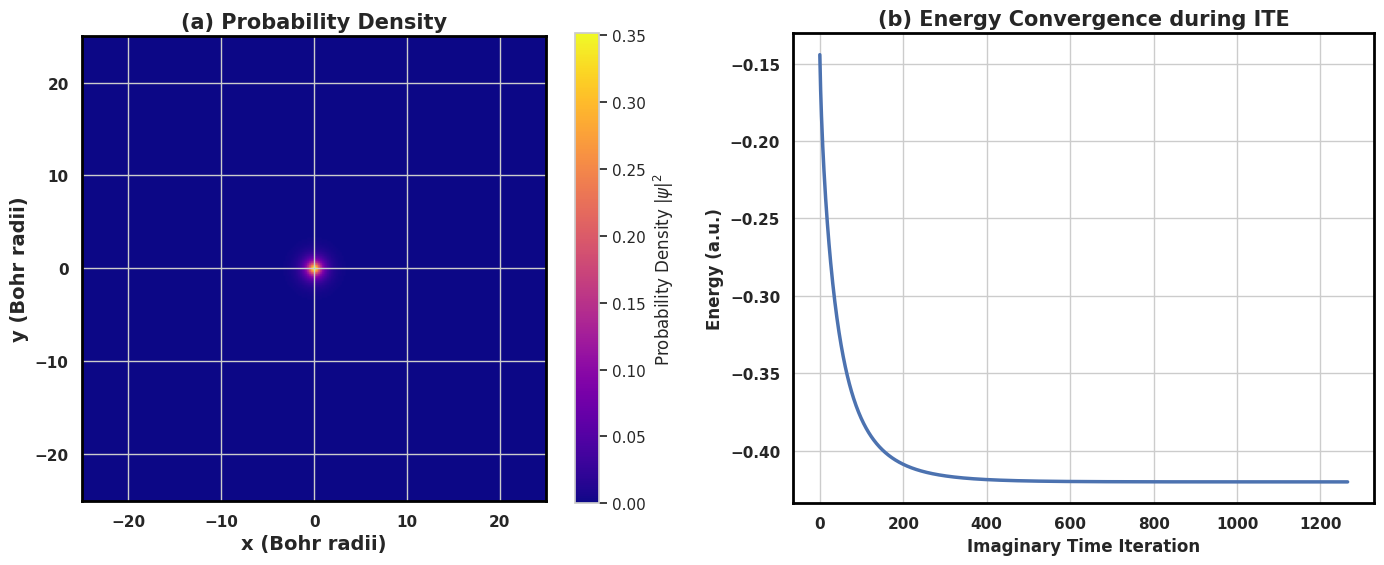

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class HydrogenAtom2D:
    """Simulates a 2D hydrogen atom to find its ground state."""
    def __init__(self, N=256, L=50.0):
        """Initializes the simulation grid and energy operators."""
        self.N, self.L, self.dx = N, L, L / N
        x_vec = np.linspace(-L / 2, L / 2, N)
        self.X, self.Y = np.meshgrid(x_vec, x_vec)

        # Set up operators for kinetic (T) and potential (V) energy
        self.T_op = self._get_kinetic_operator()
        self.V_op = self._get_potential_operator()

    def _get_kinetic_operator(self):
        """Creates the kinetic energy operator in momentum space (using atomic units hbar=1, m=1)."""
        k_vec = 2 * np.pi * np.fft.fftfreq(self.N, d=self.dx)
        KX, KY = np.meshgrid(k_vec, k_vec)
        return (KX**2 + KY**2) / 2.0

    def _get_potential_operator(self):
        """Creates the Coulomb potential operator, adding a small value to avoid division by zero."""
        r = np.sqrt(self.X**2 + self.Y**2)
        return -0.5 / np.sqrt(r**2 + 1e-6)

    def get_energy(self, psi):
        """Calculates the total energy <ψ|H|ψ> for a given wavefunction."""
        psi_k = np.fft.fft2(psi)
        T_expect = np.sum(np.conj(psi) * np.fft.ifft2(self.T_op * psi_k)).real
        V_expect = np.sum(np.abs(psi)**2 * self.V_op).real
        return (T_expect + V_expect) * self.dx**2

    def get_ground_state(self, max_iter=2000, tolerance=1e-8, dt=0.01):
        """Finds the ground state via imaginary time evolution, which 'cools' a guess to the lowest energy state."""
        # Start with a simple Gaussian blob as an initial guess
        psi = np.exp(-(self.X**2 + self.Y**2))
        psi /= np.sqrt(np.sum(np.abs(psi)**2) * self.dx**2) # Normalize

        last_energy = self.get_energy(psi)
        print("--- Finding Ground State ---")
        energy_history = [last_energy] # Store initial energy

        for i in range(max_iter):
            # Evolve using the split-step Fourier method
            psi *= np.exp(-self.V_op * dt / 2.0)
            psi = np.fft.ifft2(np.fft.fft2(psi) * np.exp(-self.T_op * dt))
            psi *= np.exp(-self.V_op * dt / 2.0)
            psi /= np.sqrt(np.sum(np.abs(psi)**2) * self.dx**2) # Re-normalize each step

            # Check for convergence
            current_energy = self.get_energy(psi)
            energy_history.append(current_energy) # Store current energy

            if i % 100 == 0:
                print(f"Iteration {i:4d}: Energy = {current_energy:.6f} a.u.")
            if abs(current_energy - last_energy) < tolerance:
                print(f"\nConvergence reached after {i+1} iterations.")
                return psi, current_energy, energy_history
            last_energy = current_energy

        print("\nMaximum iterations reached.")
        return psi, last_energy, energy_history

# ===================================================================
# --- MAIN SCRIPT ---
# ===================================================================
if __name__ == "__main__":
    # 1. Create and run the simulation
    h_atom = HydrogenAtom2D()
    psi_gs, energy_gs, energy_history = h_atom.get_ground_state()

    # 2. Print final energy and plot the result
    print(f"\nFinal Ground State Energy: {energy_gs:.6f} a.u.")

    sns.set_theme(style="whitegrid") # Use a seaborn style for better aesthetics

    # Create a figure with two subplots side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Probability Density
    ax1 = axes[0]
    prob_density = np.abs(psi_gs)**2
    im = ax1.imshow(prob_density, cmap='plasma', # Changed colormap from 'inferno' to 'plasma'
               extent=[-h_atom.L/2, h_atom.L/2, -h_atom.L/2, h_atom.L/2],
               origin='lower', aspect='equal') # Added aspect='equal' for correct aspect ratio
    fig.colorbar(im, ax=ax1, label=r'Probability Density $|\psi|^2$')
    ax1.set_title('(a) Probability Density', fontsize=15, fontweight='bold') # Made title bold and increased font size, added (a)
    ax1.set_xlabel('x (Bohr radii)', fontsize=14, fontweight='bold') # Made label bold and increased font size
    ax1.set_ylabel('y (Bohr radii)', fontsize=14, fontweight='bold') # Made label bold and increased font size

    # Make axes lines bold and thicker for the probability density plot
    for spine in ax1.spines.values():
        spine.set_linewidth(2.0) # Set box line width
        spine.set_edgecolor('black')

    # Make tick labels bold
    for tick in ax1.get_xticklabels():
        tick.set_weight('bold')
    for tick in ax1.get_yticklabels():
        tick.set_weight('bold')


    # Plot 2: Energy Convergence
    ax2 = axes[1]
    ax2.plot(range(len(energy_history)), energy_history, linewidth=2.5) # Set plot line width
    ax2.set_title('(b) Energy Convergence during ITE', fontsize=15, fontweight='bold') # Made title bold and increased font size, added (b)
    ax2.set_xlabel('Imaginary Time Iteration', fontsize=12, fontweight='bold') # Increased font size and made bold
    ax2.set_ylabel('Energy (a.u.)', fontsize=12, fontweight='bold') # Increased font size and made bold
    ax2.grid(True)

    # Make axes lines bold and thicker for the single energy plot
    for spine in ax2.spines.values():
        spine.set_linewidth(2.0) # Set box line width
        spine.set_edgecolor('black')

    # Make tick labels bold
    for tick in ax2.get_xticklabels():
        tick.set_weight('bold')
    for tick in ax2.get_yticklabels():
        tick.set_weight('bold')


    # Remove the overall figure title
    fig.suptitle('')

    plt.tight_layout()
    plt.show()